# **Informe Técnico de Análisis de Sentimiento: Dataset Yelp**
Nota: para hacer cualquier prueba de los modelos se tiene que ejecutar la celda 1.2 (librerias, dataset) y 1.4 (procesamiento de datos), se recomienda no ejeuctar todo el Coolab por el tiempo que puede tardar todos los modelos de entrenamineto.

# ***Valor de sentimiento en reseñas de YELP***
<img src="https://raw.githubusercontent.com/xxrairexx/Analisis_de_Sentimiento/78d8bca36c78d784f39bb1bb29d14b5c8b09ab02/img/Banner%20proyecto.png"
     width="800" height="300">


## **Primera Parte**
### *Informacion y preparacion de datos*

---
---

### **1.1 Analisis de los datos**

- Motivación, Problema y Datos.
- Justificación de la IA.
- Variable Objetivo.
- Análisis de Distribuciones (Estándares EDA).
- Calidad de Datos y Patrones.
- Conclusiones y Próximos Pasos.
---

#### **Motivación, Problema y Datos**
- **Origen:** Dataset `yelp_review_full` con **650,000 reseñas**.
- **Link:** https://huggingface.co/datasets/Yelp/yelp_review_full
- **Importancia:** Automatizar la gestión de reputación para manejar volúmenes masivos de feedback.
- **Desafíos:** Ambigüedad lingüística y alta variabilidad en la extensión de los textos.

#### **Justificación de la IA**
- **Escalabilidad:** Procesamiento de medio millón de registros de forma casi instantánea.
- **Consistencia:** Clasificación objetiva sin la fatiga o sesgo de un revisor humano.

#### **Variable Objetivo**
- **Definición:** Variable Categórica `label` (calificación por numero de estrellas).
- **Estadísticas:** El dataset presenta una ditribución uniforme de reseñas por calificación por número de estrellas.

#### **Análisis de Distribuciones (Estándares EDA)**
- **Distribución de Clases:** Se utilizaron gráficos de barras para mostrar la frecuencia de cada categoría de sentimiento.
- **Métricas de Texto (Variable Numérica Asimétrica):** Debido a la presencia de valores atípicos y sesgo, se analizó el `word_count` mediante la mediana y el rango.
  - **Mediana:** 99.0 palabras.
  - **Rango Intercuartil (IQR):** 123.0 (Q1: 52.0, Q3: 175.0).
  - **Justificación:** Se optó por Boxplots y la mediana ya que la media se ve afectada por reseñas extremadamente largas (hasta 1,052 palabras).

#### **Calidad de Datos y Patrones**
- **Manejo de Datos:** No hay valores nulos. Los valores atípicos (reseñas muy largas) se mantienen para análisis, pero se identifican claramente en los diagramas de caja.
- **Insights:** Los usuarios que dejan reseñas negativas (1-3 estrellas) tienden a ser más descriptivos y extensos que aquellos que dejan reseñas positivas.

#### **Conclusiones y Próximos Pasos**
- **Hallazgos:** El dataset está desbalanceado (60/40), lo cual debe considerarse al elegir las métricas de evaluación del modelo (ej. F1-Score en lugar de Accuracy).


### **1.2 Carga y Preparación de Datos, imporate de Ejectuar**


En esta sección importamos las librerías necesarias y cargamos el dataset completo de Yelp.

- Librerias.
- Cargar el dataset.
- Mostrar datos.
- Infomracion del dataset.
---



In [ ]:

#@title #### *Libs*
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import re
import nltk
import seaborn as sns
import gc, warnings
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from nltk.corpus import stopwords
from collections import Counter
from nltk.stem import WordNetLemmatizer
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MaxAbsScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster import hierarchy
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    v_measure_score,
    fowlkes_mallows_score,
    matthews_corrcoef,
    cohen_kappa_score
)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:

#@title #### *Carga del dataset*

splits = {'train': 'yelp_review_full/train-00000-of-00001.parquet', 'test': 'yelp_review_full/test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/Yelp/yelp_review_full/" + splits["train"])

df_test = pd.read_parquet("hf://datasets/Yelp/yelp_review_full/" + splits["test"])


In [ ]:

#@title #### *Head de los datos*
display(df.head())


,label,text
0,4,dr. goldberg offers everything i look for in a...
1,1,"Unfortunately, the frustration of being Dr. Go..."
2,3,Been going to Dr. Goldberg for over 10 years. ...
3,3,Got a letter in the mail last week that said D...
4,0,I don't know what Dr. Goldberg was like before...


In [ ]:

#@title #### *Información del dataset*

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   label   650000 non-null  int64 
 1   text    650000 non-null  object
dtypes: int64(1), object(1)
memory usage: 9.9+ MB


### **1.3  Análisis Exploratorio de Datos (EDA)**
- Distribución de Ratings Originales.
- Análisis de Variables Numéricas Asimétricas.
  - Distribución de Ratings Originales.
  - Estadisticas sobre los caracteres y las palabras en el dataset.
  - Average Word Count per Label.
  - Análisis de palabras según cantidad de caracteres
---


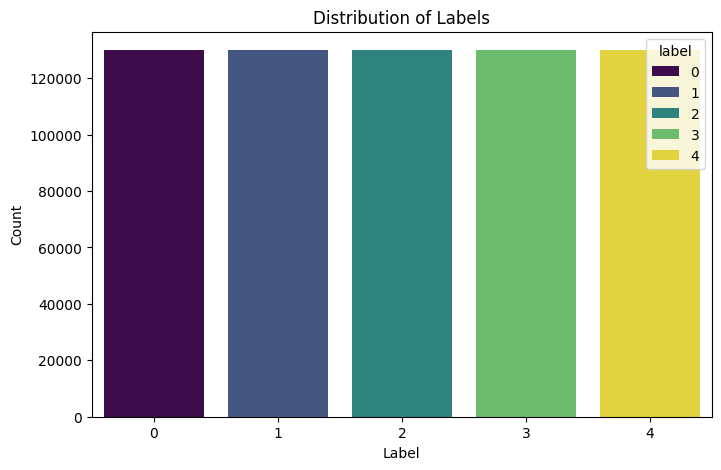

In [ ]:
#@title  ### *1 Distribución de Ratings Originales*
#@markdown Visualizamos cómo se distribuyen las calificaciones de 1 a 5 estrellas.

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, hue='label', palette='viridis')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


#### *2 Análisis de Variables Numéricas Asimétricas*
Calculamos la longitud del texto y el conteo de palabras para identificar posibles patrones en la extensión de las reseñas.



In [ ]:

#@title #### *2.1 Estadisticas sobre los caracteres y las palabras en el dataset*

# 2. Add text length columns for analysis
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("Summary Statistics for Text Length:")
display(df[['text_length', 'word_count']].describe())


Summary Statistics for Text Length:


,text_length,word_count
count,650000.000000,650000.000000
mean,732.325468,134.098089
std,663.721184,121.396115
min,1.000000,1.000000
25%,287.000000,52.000000
50%,539.000000,99.000000
75%,957.000000,175.000000
max,5637.000000,1052.000000


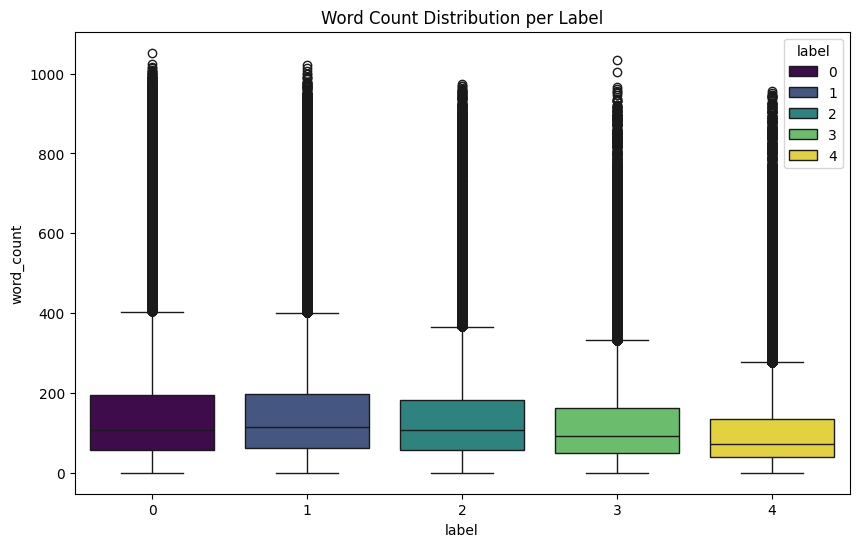

In [ ]:

#@title #### *2.2 Average Word Count per Label*
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='word_count', data=df, hue='label', palette='viridis')
plt.title('Word Count Distribution per Label')

plt.show()


#### *2.3 Análisis de palabras según cantidad de caracteres*

In [ ]:
#@title #### Texto con menos carateres
shortest_char_idx = df['text_length'].idxmin()
shortest_word_idx = df['word_count'].idxmin()

longest_char_idx = df['text_length'].idxmax()
longest_word_idx = df['word_count'].idxmax()

df.iloc[shortest_char_idx]

,1014
label,0
text,A
text_length,1
word_count,1


In [ ]:
#@title #### Texto con menos palabras
df.iloc[shortest_word_idx]

,28
label,1
text,Hoofah.
text_length,7
word_count,1


In [ ]:
#@title #### Texto con mas caracteres
df.loc[longest_char_idx]

,614419
label,3
text,"Pour le jour de l'an 2010, nous \u00e9tions a ..."
text_length,5637
word_count,877


In [ ]:
#@title #### Texto con mas palabras
df.loc[longest_word_idx]


,241540
label,0
text,I made my appointment for a yearly PAP & seen ...
text_length,4978
word_count,1052


### 1.4 Análisis de Contenido y NLP
- Word's Heat Map.
- Procesamiento, normalización de datos.
- Palabras dentro de cada estrella.


---

In [ ]:

#@title Word's Heat Map

"""
Yelp Review NLP Pipeline
------------------------

Merges EDA + feature engineering into a single, clean script.
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# ─────────────────────────────────────────────
# 2. EDA – BETTER WORD VISUALIZATION
#    TF-IDF heatmap: most *distinctive* words per rating
# ─────────────────────────────────────────────

def plot_tfidf_heatmap_improved(df, n_words=20, sample_per_label=5000, random_state=42):
    """
    For each star rating, compute the mean TF-IDF score of the top N words.
    Visualises a heatmap so you can see which words distinguish each rating
    instead of just which words appear most often overall.
    Improved version with a light theme and readable colors.
    """
    rating_labels = {0: '★☆☆☆☆', 1: '★★☆☆☆', 2: '★★★☆☆', 3: '★★★★☆', 4: '★★★★★'}

    # Sample for speed (if df is large)
    sampled = (
        df.groupby('label', group_keys=False)
          .apply(lambda g: g.sample(min(sample_per_label, len(g)), random_state=random_state))
    )

    # TF-IDF over the whole sample to get a shared vocabulary
    # sublinear_tf=True scales tf with 1 + log(tf) for better robustness.
    tfidf = TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=5,
    )
    X = tfidf.fit_transform(sampled['text'].fillna(''))
    vocab = np.array(tfidf.get_feature_names_out())

    # Mean TF-IDF per label
    label_scores = {}
    for label in sorted(df['label'].unique()):
        mask = (sampled['label'] == label).values
        mean_scores = np.asarray(X[mask].mean(axis=0)).flatten()
        label_scores[label] = mean_scores

    scores_df = pd.DataFrame(label_scores, index=vocab)
    # Map the labels to the star emoji strings
    scores_df.columns = [rating_labels[c] for c in scores_df.columns]

    # Pick the top N words that have the highest *max* score across any rating
    top_words = scores_df.max(axis=1).nlargest(n_words).index
    # Sort the final DataFrame by the 5-star rating scores in descending order
    plot_df = scores_df.loc[top_words].sort_values(rating_labels[4], ascending=False)

    # ── Plot ──────────────────────────────────
    # Create the figure with a clear white background (default)
    fig, ax = plt.subplots(figsize=(11, 9))

    # 1. Clear color settings
    # We remove the fig.patch.set_facecolor and ax.set_facecolor calls.
    # Text and annotation color should be dark for readability on light cells.
    text_color = '#333333' # Charcoal grey

    # 2. Optimized colormap for non-negative scores (sequential)
    # 'YlGnBu' goes from light yellow to deep blue.
    cmap = 'YlGnBu'

    # 3. Use seaborn's heatmap with explicit dark annotations
    sns.heatmap(
        plot_df,
        ax=ax,
        cmap=cmap,
        linewidths=0.6,
        linecolor='#e0e0e0', # Subtle light grey grid lines
        annot=True,
        fmt='.3f',
        # Set annotation color to dark charcoal grey
        annot_kws={'size': 9, 'color': text_color},
        cbar_kws={'shrink': 0.7, 'label': 'Mean TF-IDF score'},
    )

    # 4. Final label and tick customization for readability
    ax.set_title(
        'Most Distinctive Words per Star Rating\n(mean TF-IDF — higher = more characteristic of that rating)',
        fontsize=14, fontweight='bold', color=text_color, pad=18,
    )
    ax.set_xlabel('Star Rating', fontsize=12, color=text_color, labelpad=10)
    ax.set_ylabel('Word / Bigram', fontsize=12, color=text_color, labelpad=10)

    # Tick color and size for better visual flow
    ax.tick_params(colors=text_color, labelsize=10)
    plt.setp(ax.get_xticklabels(), rotation=0)
    plt.setp(ax.get_yticklabels(), rotation=0)

    # Colorbar label and tick color
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(colors=text_color, labelsize=9)
    cbar.set_label('Mean TF-IDF score', color=text_color, fontsize=10)

    plt.tight_layout(pad=2.0)
    # Adjust output facecolor just in case, though the figure is now clear.
    plt.savefig('word_heatmap_improved.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved improved plot → word_heatmap_improved.png")

# Assuming 'df' is defined. Call the improved function:
# plot_tfidf_heatmap_improved(df, n_words=20)

/tmp/ipykernel_2282/4004161969.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(sample_per_label, len(g)), random_state=random_state))


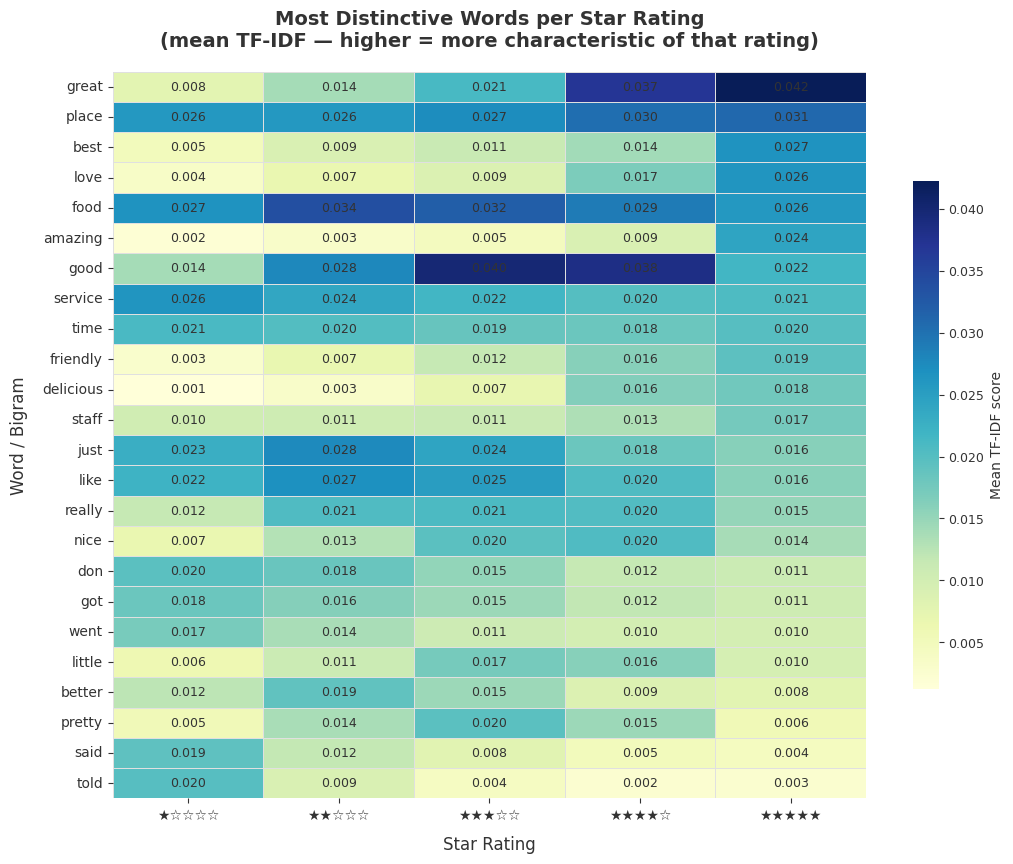

Saved improved plot → word_heatmap_improved.png


In [ ]:
plot_tfidf_heatmap_improved(df, n_words=24)

In [ ]:
#@title #### *Procesamiento*


stop_words = set(stopwords.words('english'))

# Update the function to exclude stopwords
def get_top_n_words_filtered(corpus, n=None, n_gram=1):
    words = []
    for text in corpus:
        text = text.lower()
        tokens = re.findall(r'\b\w+\b', text)
        # Filter out stopwords and very short tokens
        tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

        if n_gram > 1:
            tokens = [' '.join(tokens[i:i+n_gram]) for i in range(len(tokens)-n_gram+1)]
        words.extend(tokens)

    return Counter(words).most_common(n)

df_sample = df.sample(n=50000, random_state=42)

X_text = df_sample["text"]
y = df_sample["label"]

# ─────────────────────────────────────────
# CONFIGURACIÓN — ajusta según tu RAM
# ─────────────────────────────────────────
MAX_FEATURES_WORD = 12000 # baja a 8000 si sigues justo
MAX_FEATURES_CHAR = 4000 # baja a 2000 si sigues justo

# ─────────────────────────────────────────
# 1. NEGACIONES
# ─────────────────────────────────────────

NEGACIONES = { "not", "no", "never", "neither", "nor",
              "barely", "hardly", "scarcely", "without",
              "don't", "doesn't", "didn't", "won't",
              "wouldn't", "isn't", "aren't", "wasn't",
              "weren't", "couldn't", "shouldn't"
              }


def manejar_negaciones(texto, ventana=3):
   palabras = texto.split()
   resultado = []
   negar = 0
   for palabra in palabras:
        if palabra in NEGACIONES:
            resultado.append(palabra)
            negar = ventana
        elif negar > 0:
            resultado.append("NOT_" + palabra)
            negar -= 1
        else:
            resultado.append(palabra)
   return ' '.join(resultado)

# ─────────────────────────────────────────
# 2. LEMMATIZACIÓN + LIMPIEZA
# ─────────────────────────────────────────
lemmatizer = WordNetLemmatizer()

def preprocesar(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+', '', texto)
    texto = re.sub(r"[^a-zA-Z\s']", ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    texto = manejar_negaciones(texto)
    palabras = texto.split()
    palabras = ["NOT_" + lemmatizer.lemmatize(p[4:]) if p.startswith("NOT_") else lemmatizer.lemmatize(p) for p in palabras]
    return ' '.join(palabras)

# ─────────────────────────────────────────
# 3. APLICAR PREPROCESAMIENTO
# ─────────────────────────────────────────
print("Preprocesando texto... (puede tardar un par de minutos)")
df_sample['text_proc'] = df_sample['text'].apply(preprocesar)
print("Listo.")

# ─────────────────────────────────────────
# 4. FEATURES MANUALES (bajo costo de memoria)
# ─────────────────────────────────────────
def extraer_features_extra(textos_originales):
    feats = {
        'exclamaciones':     textos_originales.apply(lambda x: min(x.count('!'), 10)),
        'mayusculas_ratio':  textos_originales.apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)),
        'signos_pregunta':   textos_originales.apply(lambda x: min(x.count('?'), 5)),
        'word_count_log':    textos_originales.apply(lambda x: np.log1p(len(x.split()))),
    }
    return csr_matrix(pd.DataFrame(feats).values)
# ─────────────────────────────────────────
# 5. SPLIT
# ─────────────────────────────────────────


X_train_text_proc, X_test_text_proc, \
X_train_text_orig, X_test_text_orig, \
y_train, y_test = train_test_split(
   df_sample['text_proc'],
   df_sample['text'],
   df_sample['label'],
   test_size=0.2,
   random_state=42,
   stratify=df_sample['label']
)



# Vectorización Dual (Palabras + Caracteres)
# ─────────────────────────────────────────────
# 7. VECTORISATION  (word TF-IDF + char TF-IDF + hand-crafted)
# ─────────────────────────────────────────────
tfidf_word = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), max_features=MAX_FEATURES_WORD, sublinear_tf=True, min_df=3, dtype=np.float32)
tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4), max_features=MAX_FEATURES_CHAR, sublinear_tf=True, min_df=5, dtype=np.float32)

print("Vectorizando y combinando características...")
X_train_word = tfidf_word.fit_transform(X_train_text_proc)
X_test_word = tfidf_word.transform(X_test_text_proc)

X_train_char = tfidf_char.fit_transform(X_train_text_proc)
X_test_char = tfidf_char.transform(X_test_text_proc)

X_train_extra = extraer_features_extra(X_train_text_orig)
X_test_extra = extraer_features_extra(X_test_text_orig)

X_train_final = hstack([X_train_word, X_train_char, X_train_extra], format='csr')
X_test_final = hstack([X_test_word, X_test_char, X_test_extra], format='csr')

print(f"Procesamiento completo. Shape final: {X_train_final.shape}")

Preprocesando texto... (puede tardar un par de minutos)
Listo.
Vectorizando y combinando características...
Procesamiento completo. Shape final: (40000, 16004)


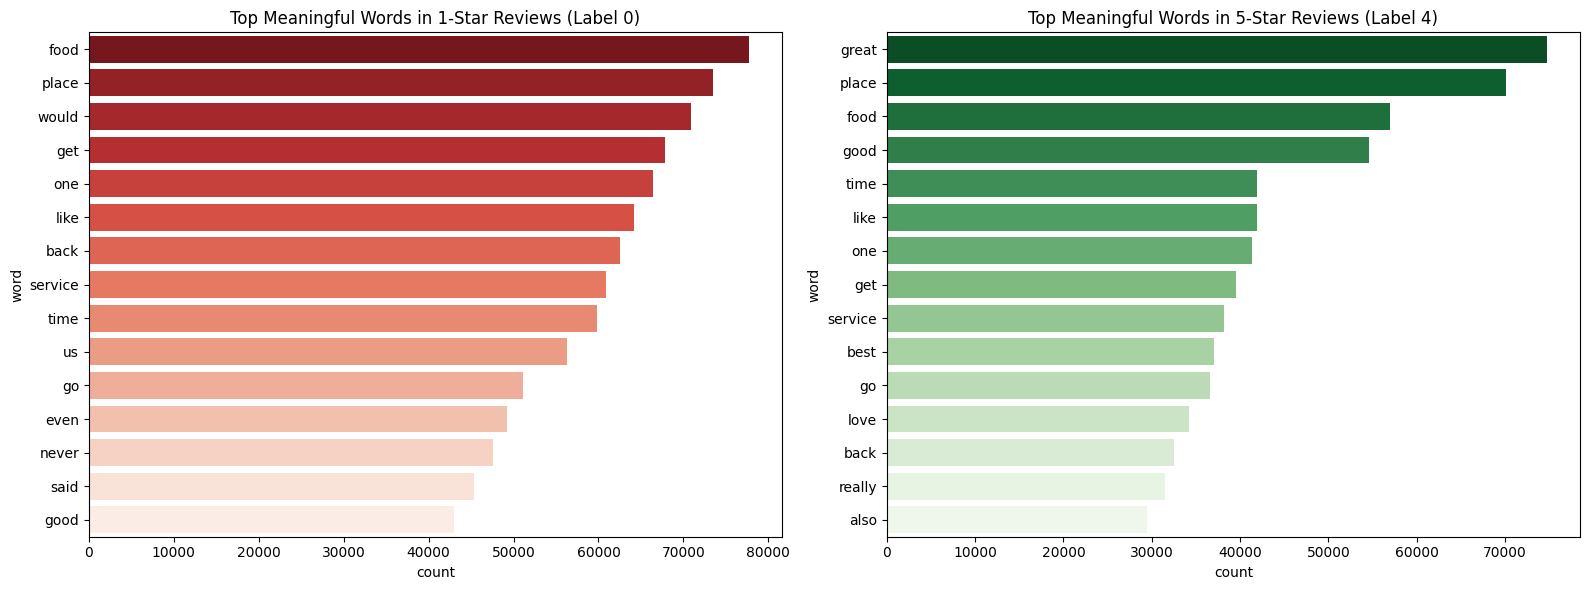

In [ ]:
#@title ####Palabras dentro de cada estrella

# Get top words for both classes

# Update the function to exclude stopwords
def get_top_n_words_filtered(corpus, n=None, n_gram=1):
    words = []
    for text in corpus:
        text = text.lower()
        tokens = re.findall(r'\b\w+\b', text)
        # Filter out stopwords and very short tokens
        tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

        if n_gram > 1:
            tokens = [' '.join(tokens[i:i+n_gram]) for i in range(len(tokens)-n_gram+1)]
        words.extend(tokens)

    return Counter(words).most_common(n)
top_0 = get_top_n_words_filtered(df[df['label']==0]['text'], n=15)
top_4 = get_top_n_words_filtered(df[df['label']==4]['text'], n=15)

# Convert to DataFrames for easier plotting
df_0 = pd.DataFrame(top_0, columns=['word', 'count'])
df_4 = pd.DataFrame(top_4, columns=['word', 'count'])

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='count', y='word', data=df_0, ax=ax1, hue='word', palette='Reds_r', legend=False)
ax1.set_title('Top Meaningful Words in 1-Star Reviews (Label 0)')

sns.barplot(x='count', y='word', data=df_4, ax=ax2, hue='word', palette='Greens_r', legend=False)
ax2.set_title('Top Meaningful Words in 5-Star Reviews (Label 4)')

plt.tight_layout()
plt.show()


##  ***Segunda Parte*** (no ejecutar)
### *Entrenamiento supervisado*
- *tiempo estimado para todos los modelos (~1 hora y 20 minutos)*

---
---

### ***2.1 Preparacación de metricas***

---

In [ ]:
#@title #### *Preparar metricas*



TARGET_NAMES = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']


def especificidad_multiclase(y_true, y_pred):
    """Mean per-class specificity (TN / (TN + FP))."""
    cm = confusion_matrix(y_true, y_pred)
    especificidades = []
    for i in range(len(cm)):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP
        especificidades.append(TN / (TN + FP) if (TN + FP) > 0 else 0.0)
    return np.mean(especificidades)


def metricas_rapidas(y_true, y_pred):
    """Return a dict with the five core metrics."""
    return {
        "Accuracy"      : accuracy_score(y_true, y_pred),
        "F1-Score"      : f1_score(y_true, y_pred, average='weighted'),
        "Precision"     : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall"        : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Especificidad" : especificidad_multiclase(y_true, y_pred),
    }


def evaluar_modelo(nombre, y_true, y_pred):
    """Print full metrics report and plot confusion matrix."""
    print(f"\n{'─' * 64}")
    print(f"  MODELO: {nombre}")
    print(f"{'─' * 64}")

    m = metricas_rapidas(y_true, y_pred)
    print(f"  Exactitud      (Accuracy)    : {m['Accuracy']:.4f}")
    print(f"  Precisión      (Weighted)    : {m['Precision']:.4f}")
    print(f"  Sensibilidad   (Recall)      : {m['Recall']:.4f}")
    print(f"  F1-Score       (Weighted)    : {m['F1-Score']:.4f}")
    print(f"  Especificidad  (Specificity) : {m['Especificidad']:.4f}")
    print("\n  Reporte de Clasificación:")
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
    )
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()


def graficar_ablation(df_ab, param_nombre, modelo_nombre):
    """Plot all five metrics vs. a hyperparameter for an ablation study."""
    metricas = ["Accuracy", "F1-Score", "Precision", "Recall", "Especificidad"]
    fig, axes = plt.subplots(1, len(metricas), figsize=(20, 4))
    for ax, metrica in zip(axes, metricas):
        ax.plot(df_ab[param_nombre], df_ab[metrica], marker='o', color='steelblue')
        ax.set_title(metrica)
        ax.set_xlabel(param_nombre)
        ax.set_ylabel("Score")
        ax.grid(True, linestyle='--', alpha=0.5)
        idx_best = df_ab[metrica].idxmax()
        ax.axvline(
            x=df_ab.loc[idx_best, param_nombre],
            color='red', linestyle=':', alpha=0.7,
            label=f"mejor={df_ab.loc[idx_best, param_nombre]}",
        )
        ax.legend(fontsize=8)
    fig.suptitle(f"Ablation Study — {modelo_nombre}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### **2.2Modelos de clacificación** (No ejecutar)
- Multinomial Naive Bayes (~7 segundos)
- Decision Tree (~48 minutos)
- Random Forest (~22 minutos)
- Support Vector Machine (SVM)(~9 minutos)
- Grafica Comparativa
---

Ablation Study: Multinomial Naive Bayes (alpha)…
  alpha=0.01  | F1=0.5434 | 0.7s  ← mejor hasta ahora
  alpha=0.05  | F1=0.5434 | 0.7s  ← mejor hasta ahora
  alpha=0.1   | F1=0.5429 | 0.7s
  alpha=0.5   | F1=0.5419 | 0.7s
  alpha=1.0   | F1=0.5404 | 0.7s
  alpha=2.0   | F1=0.5372 | 0.9s

Resumen Ablation Multinomial Naive Bayes:



,alpha,Tiempo(s),Accuracy,F1-Score,Precision,Recall,Especificidad
0,2.00,0.91,0.5408,0.537204,0.537480,0.5408,0.885136
1,1.00,0.71,0.5434,0.540407,0.540441,0.5434,0.885787
2,0.50,0.72,0.5443,0.541855,0.541936,0.5443,0.886011
3,0.10,0.74,0.5447,0.542893,0.543257,0.5447,0.886108
4,0.05,0.67,0.5451,0.543414,0.543866,0.5451,0.886208
5,0.01,0.73,0.5449,0.543352,0.543908,0.5449,0.886157


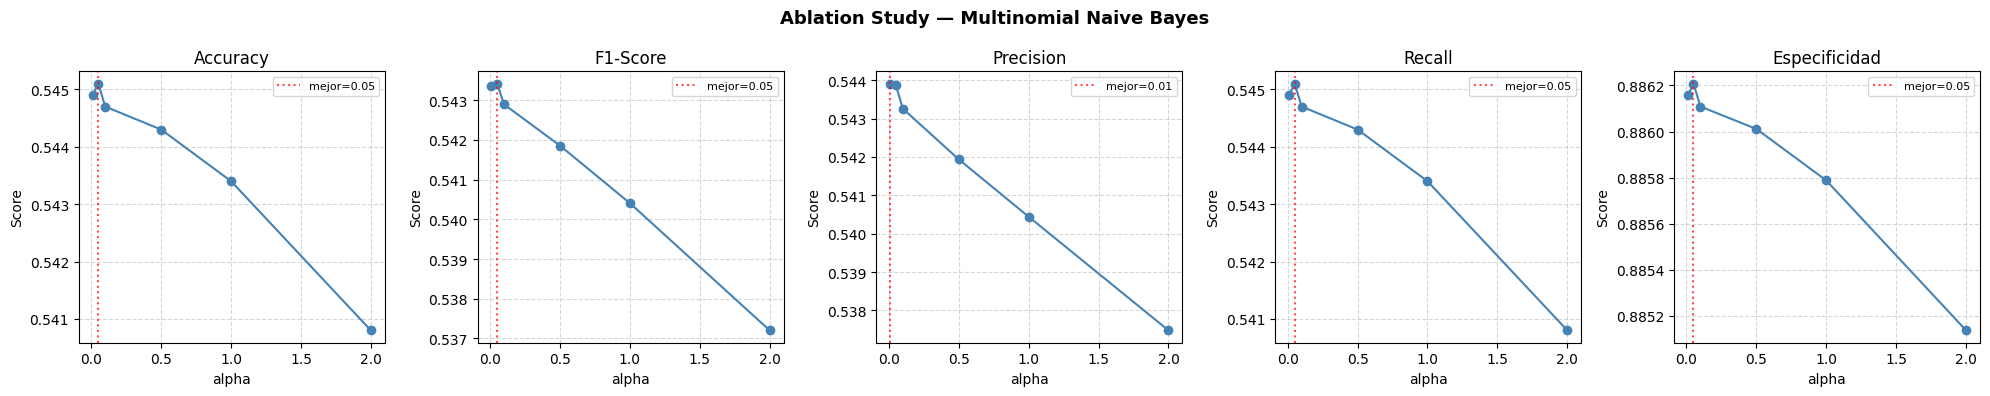


Mejor configuración: alpha=0.05
Entrenamiento final: 0.56s

────────────────────────────────────────────────────────────────
  MODELO: Multinomial Naive Bayes
────────────────────────────────────────────────────────────────
  Exactitud      (Accuracy)    : 0.5451
  Precisión      (Weighted)    : 0.5439
  Sensibilidad   (Recall)      : 0.5451
  F1-Score       (Weighted)    : 0.5434
  Especificidad  (Specificity) : 0.8862

  Reporte de Clasificación:
              precision    recall  f1-score   support

      1 Star       0.62      0.70      0.66      2010
     2 Stars       0.47      0.42      0.45      1993
     3 Stars       0.47      0.48      0.47      2019
     4 Stars       0.50      0.51      0.50      2026
     5 Stars       0.66      0.61      0.64      1952

    accuracy                           0.55     10000
   macro avg       0.54      0.55      0.54     10000
weighted avg       0.54      0.55      0.54     10000



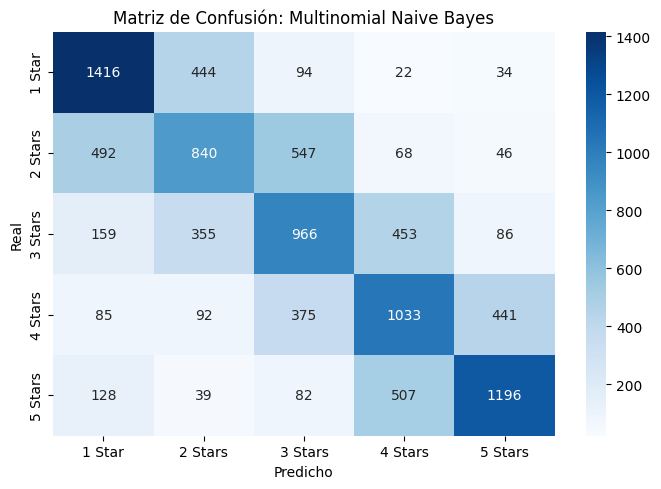

In [ ]:
#@title ###*1. Multinomial Naive Bayes*
print("Ablation Study: Multinomial Naive Bayes (alpha)…")
resultados_mnb = []
mejor_f1_mnb   = -1
mejor_alpha    = None

for alpha_val in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]:
    t0 = time.time()
    mnb_ab = MultinomialNB(alpha=alpha_val)
    mnb_ab.fit(X_train_final, y_train)
    y_pred_val = mnb_ab.predict(X_test_final)
    elapsed = time.time() - t0

    row = {"alpha": alpha_val, "Tiempo(s)": round(elapsed, 2)}
    row.update(metricas_rapidas(y_test, y_pred_val))
    resultados_mnb.append(row)

    marca = ""
    if row["F1-Score"] > mejor_f1_mnb:
        mejor_f1_mnb = row["F1-Score"]
        mejor_alpha  = alpha_val
        marca = "  ← mejor hasta ahora"

    print(f"  alpha={alpha_val:<5} | F1={row['F1-Score']:.4f} | {elapsed:.1f}s{marca}")

df_ablation_mnb = pd.DataFrame(resultados_mnb).sort_values("alpha", ascending=False).reset_index(drop=True)
print("\nResumen Ablation Multinomial Naive Bayes:\n")
display(df_ablation_mnb)
graficar_ablation(df_ablation_mnb, "alpha", "Multinomial Naive Bayes")

# Reentrenamiento final con mejor alpha
print(f"\nMejor configuración: alpha={mejor_alpha}")
t0 = time.time()
mejor_modelo_mnb = MultinomialNB(alpha=mejor_alpha)
mejor_modelo_mnb.fit(X_train_final, y_train)
print(f"Entrenamiento final: {time.time() - t0:.2f}s")
y_pred_mnb = mejor_modelo_mnb.predict(X_test_final)
evaluar_modelo("Multinomial Naive Bayes", y_test, y_pred_mnb)

Ablation Study: Decision Tree (max_depth)…
  max_depth=5   | F1=0.3422 | 71.9s  ← mejor hasta ahora
  max_depth=10  | F1=0.3652 | 203.7s  ← mejor hasta ahora
  max_depth=15  | F1=0.3763 | 356.1s  ← mejor hasta ahora
  max_depth=20  | F1=0.3680 | 536.8s
  max_depth=24  | F1=0.3579 | 613.1s
  max_depth=30  | F1=0.3531 | 728.0s

Resumen Ablation Decision Tree:



,max_depth,Tiempo(s),Accuracy,F1-Score,Precision,Recall,Especificidad
0,30,727.99,0.3517,0.353097,0.355714,0.3517,0.837875
1,24,613.08,0.3557,0.357917,0.362581,0.3557,0.838867
2,20,536.77,0.3662,0.367983,0.370884,0.3662,0.841496
3,15,356.11,0.3759,0.376252,0.377031,0.3759,0.843925
4,10,203.69,0.3789,0.365204,0.371527,0.3789,0.844631
5,5,71.93,0.3381,0.342177,0.388518,0.3381,0.834515


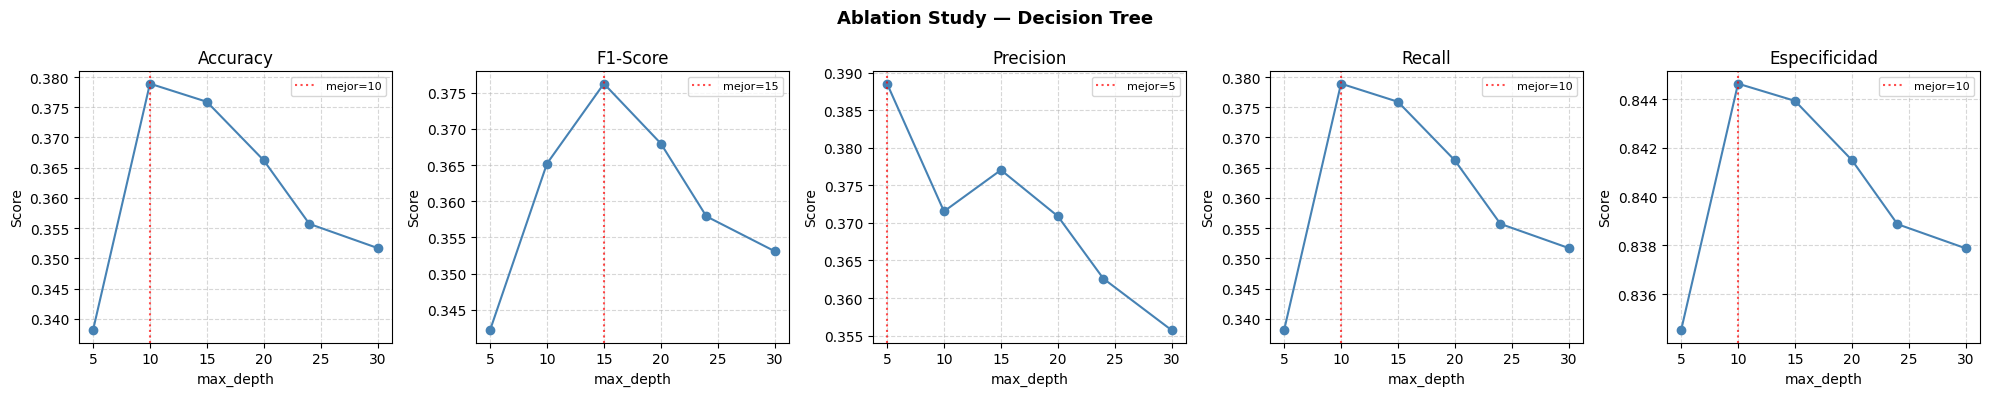


Mejor configuración: max_depth=15
Entrenamiento final: 365.32s

────────────────────────────────────────────────────────────────
  MODELO: Decision Tree
────────────────────────────────────────────────────────────────
  Exactitud      (Accuracy)    : 0.3759
  Precisión      (Weighted)    : 0.3770
  Sensibilidad   (Recall)      : 0.3759
  F1-Score       (Weighted)    : 0.3763
  Especificidad  (Specificity) : 0.8439

  Reporte de Clasificación:
              precision    recall  f1-score   support

      1 Star       0.48      0.49      0.48      2010
     2 Stars       0.30      0.30      0.30      1993
     3 Stars       0.32      0.32      0.32      2019
     4 Stars       0.34      0.36      0.35      2026
     5 Stars       0.45      0.41      0.43      1952

    accuracy                           0.38     10000
   macro avg       0.38      0.38      0.38     10000
weighted avg       0.38      0.38      0.38     10000



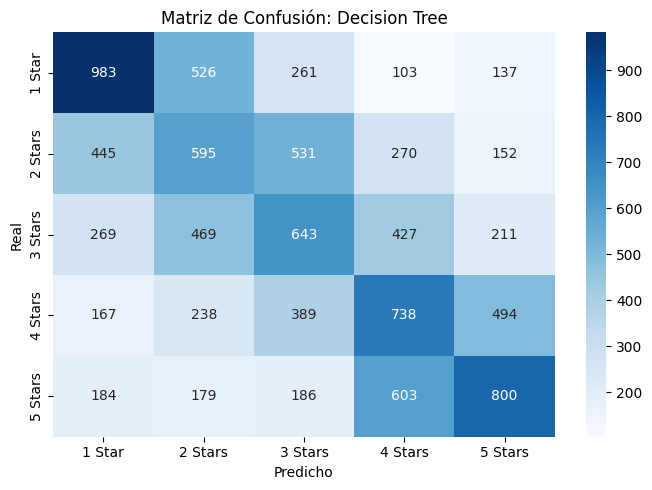

In [ ]:
#@title ### *2. Decision Tree*

print("Ablation Study: Decision Tree (max_depth)…")
resultados_dt  = []
mejor_f1_dt    = -1
mejor_depth    = None

for depth in [5, 10, 15, 20, 24, 30]:
    t0 = time.time()
    dt_ab = DecisionTreeClassifier(max_depth=depth, min_samples_split=12, random_state=42)
    dt_ab.fit(X_train_final, y_train)         # ← split principal
    y_pred_val = dt_ab.predict(X_test_final)  # ← test real
    elapsed = time.time() - t0

    row = {"max_depth": depth, "Tiempo(s)": round(elapsed, 2)}
    row.update(metricas_rapidas(y_test, y_pred_val))  # ← y_test
    resultados_dt.append(row)

    marca = ""
    if row["F1-Score"] > mejor_f1_dt:
        mejor_f1_dt = row["F1-Score"]
        mejor_depth = depth
        marca = "  ← mejor hasta ahora"

    print(f"  max_depth={depth:<3} | F1={row['F1-Score']:.4f} | {elapsed:.1f}s{marca}")

df_ablation_dt = pd.DataFrame(resultados_dt).sort_values("max_depth", ascending=False).reset_index(drop=True)
print("\nResumen Ablation Decision Tree:\n")
display(df_ablation_dt)
graficar_ablation(df_ablation_dt, "max_depth", "Decision Tree")

# Reentrenamiento final con mejor depth
print(f"\nMejor configuración: max_depth={mejor_depth}")
t0 = time.time()
mejor_modelo_dt = DecisionTreeClassifier(max_depth=mejor_depth, min_samples_split=12, random_state=42)
mejor_modelo_dt.fit(X_train_final, y_train)
print(f"Entrenamiento final: {time.time() - t0:.2f}s")
y_pred_dt = mejor_modelo_dt.predict(X_test_final)
evaluar_modelo("Decision Tree", y_test, y_pred_dt)

Ablation Study: Random Forest (n_estimators)…
  n_estimators=20   | F1=0.4381 | 47.3s  ← mejor hasta ahora
  n_estimators=50   | F1=0.4590 | 163.6s  ← mejor hasta ahora
  n_estimators=100  | F1=0.4725 | 300.2s  ← mejor hasta ahora
  n_estimators=144  | F1=0.4731 | 456.4s  ← mejor hasta ahora

Resumen Ablation Random Forest:



,n_estimators,Tiempo(s),Accuracy,F1-Score,Precision,Recall,Especificidad
0,144,456.43,0.4842,0.473067,0.472182,0.4842,0.871039
1,100,300.24,0.4836,0.472547,0.471549,0.4836,0.870888
2,50,163.64,0.4696,0.458968,0.456994,0.4696,0.867386
3,20,47.30,0.4468,0.438065,0.435425,0.4468,0.861686


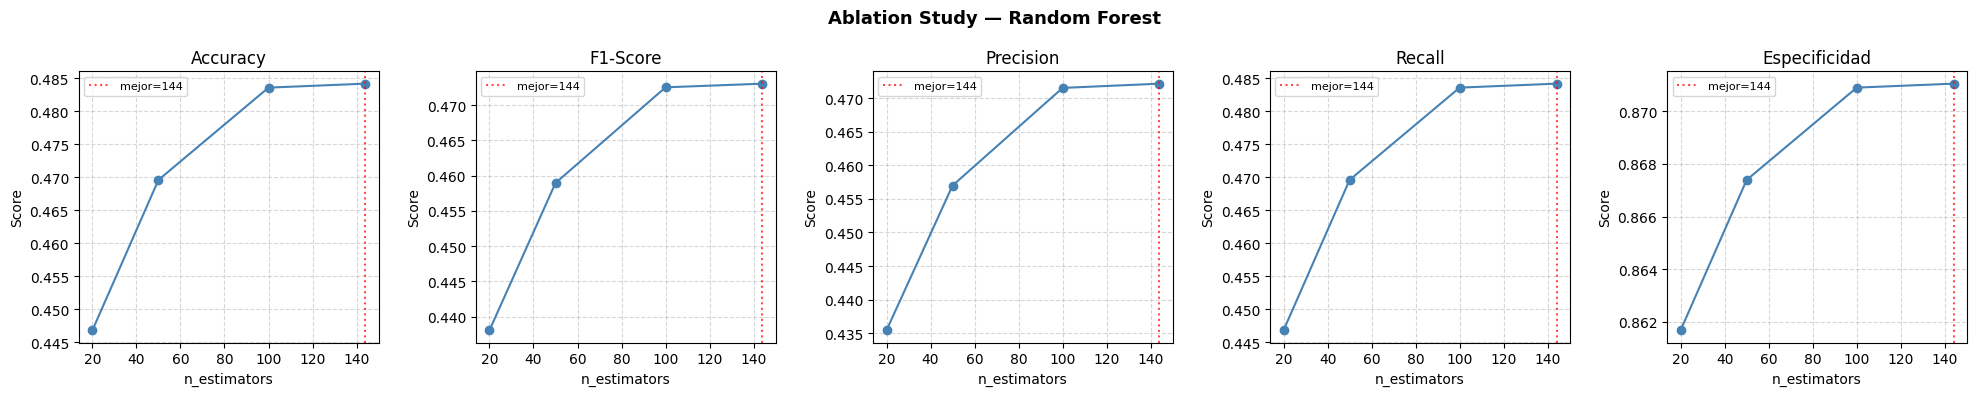


Mejor configuración: n_estimators=144
Entrenamiento final: 338.65s

────────────────────────────────────────────────────────────────
  MODELO: Random Forest
────────────────────────────────────────────────────────────────
  Exactitud      (Accuracy)    : 0.4842
  Precisión      (Weighted)    : 0.4722
  Sensibilidad   (Recall)      : 0.4842
  F1-Score       (Weighted)    : 0.4731
  Especificidad  (Specificity) : 0.8710

  Reporte de Clasificación:
              precision    recall  f1-score   support

      1 Star       0.57      0.75      0.65      2010
     2 Stars       0.42      0.32      0.37      1993
     3 Stars       0.41      0.40      0.40      2019
     4 Stars       0.43      0.35      0.39      2026
     5 Stars       0.53      0.60      0.57      1952

    accuracy                           0.48     10000
   macro avg       0.47      0.48      0.47     10000
weighted avg       0.47      0.48      0.47     10000



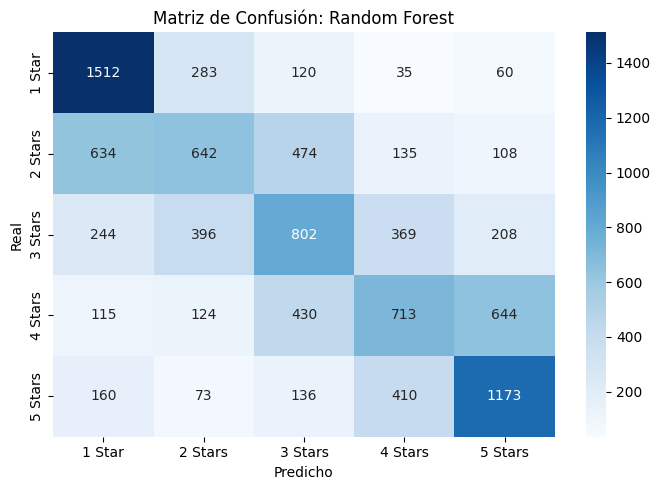

In [ ]:
#@title ### *3. Random Forest*

print("Ablation Study: Random Forest (n_estimators)…")
resultados_rf  = []
mejor_f1_rf    = -1
mejor_n_est    = None

for n_est in [20, 50, 100, 144]:
    t0 = time.time()
    rf_ab = RandomForestClassifier(n_estimators=n_est, max_depth=20, n_jobs=-1, random_state=42)
    rf_ab.fit(X_train_final, y_train)         # ← split principal
    y_pred_val = rf_ab.predict(X_test_final)  # ← test real
    elapsed = time.time() - t0

    row = {"n_estimators": n_est, "Tiempo(s)": round(elapsed, 2)}
    row.update(metricas_rapidas(y_test, y_pred_val))  # ← y_test
    resultados_rf.append(row)

    marca = ""
    if row["F1-Score"] > mejor_f1_rf:
        mejor_f1_rf = row["F1-Score"]
        mejor_n_est = n_est
        marca = "  ← mejor hasta ahora"

    print(f"  n_estimators={n_est:<4} | F1={row['F1-Score']:.4f} | {elapsed:.1f}s{marca}")

df_ablation_rf = pd.DataFrame(resultados_rf).sort_values("n_estimators", ascending=False).reset_index(drop=True)
print("\nResumen Ablation Random Forest:\n")
display(df_ablation_rf)
graficar_ablation(df_ablation_rf, "n_estimators", "Random Forest")

# Reentrenamiento final con mejor n_estimators
print(f"\nMejor configuración: n_estimators={mejor_n_est}")
t0 = time.time()
mejor_modelo_rf = RandomForestClassifier(n_estimators=mejor_n_est, max_depth=20, n_jobs=-1, random_state=42)
mejor_modelo_rf.fit(X_train_final, y_train)
print(f"Entrenamiento final: {time.time() - t0:.2f}s")
y_pred_rf = mejor_modelo_rf.predict(X_test_final)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

Ablation Study: SVM (C)…
  C=0.01  | F1=0.5622 | 50.8s  ← mejor hasta ahora
  C=0.05  | F1=0.5800 | 70.3s  ← mejor hasta ahora
  C=0.1   | F1=0.5784 | 101.4s
  C=0.5   | F1=0.5572 | 121.5s
  C=1.0   | F1=0.5466 | 149.8s

Resumen Ablation SVM:



,C,Tiempo(s),Accuracy,F1-Score,Precision,Recall,Especificidad
0,1.00,149.77,0.5491,0.546610,0.545003,0.5491,0.887244
1,0.50,121.49,0.5605,0.557193,0.555319,0.5605,0.890097
2,0.10,101.41,0.5845,0.578389,0.576729,0.5845,0.896107
3,0.05,70.34,0.5873,0.579990,0.579025,0.5873,0.896812
4,0.01,50.78,0.5729,0.562159,0.564102,0.5729,0.893229


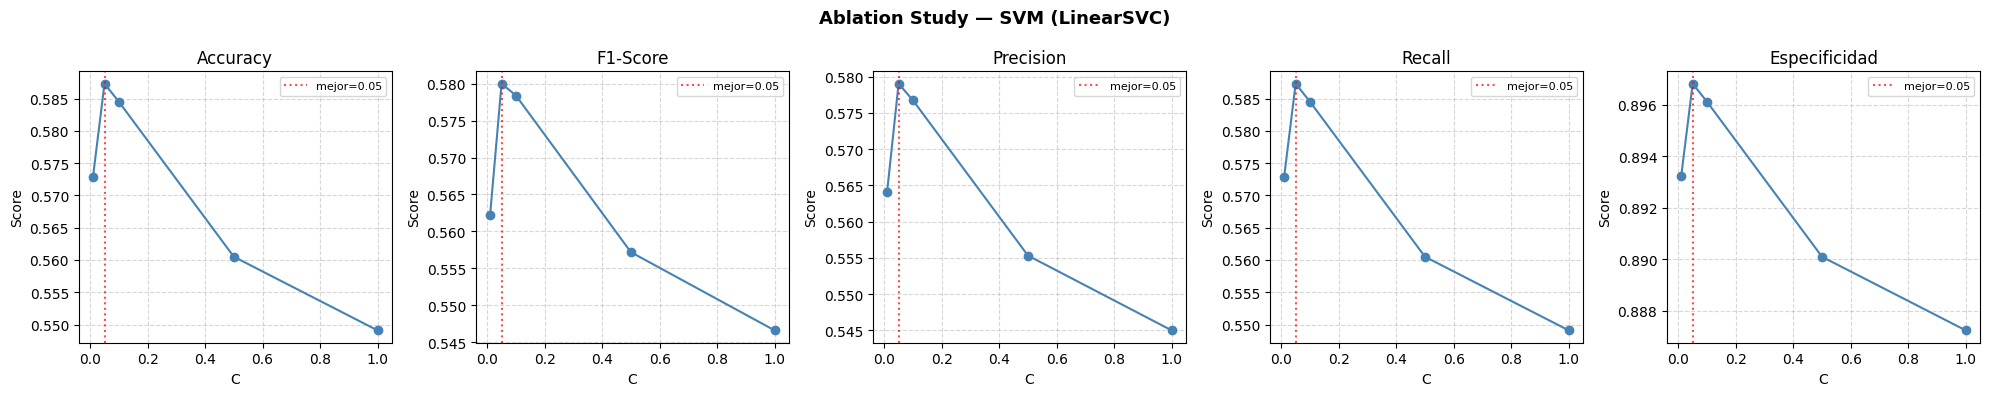


Mejor configuración: C=0.05
Entrenamiento final: 70.02s

────────────────────────────────────────────────────────────────
  MODELO: SVM (LinearSVC)
────────────────────────────────────────────────────────────────
  Exactitud      (Accuracy)    : 0.5873
  Precisión      (Weighted)    : 0.5790
  Sensibilidad   (Recall)      : 0.5873
  F1-Score       (Weighted)    : 0.5800
  Especificidad  (Specificity) : 0.8968

  Reporte de Clasificación:
              precision    recall  f1-score   support

      1 Star       0.67      0.80      0.73      2010
     2 Stars       0.55      0.46      0.50      1993
     3 Stars       0.52      0.49      0.51      2019
     4 Stars       0.52      0.45      0.49      2026
     5 Stars       0.64      0.73      0.68      1952

    accuracy                           0.59     10000
   macro avg       0.58      0.59      0.58     10000
weighted avg       0.58      0.59      0.58     10000



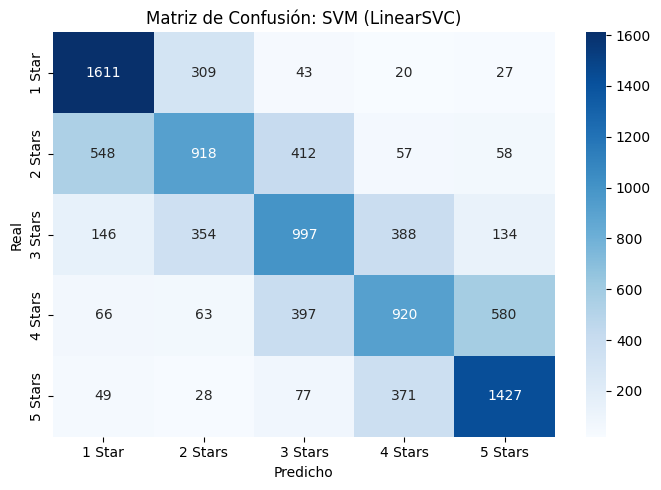

In [ ]:
#@title ### *4. Support Vector Machine (LinearSVC)*
print("Ablation Study: SVM (C)…")
resultados_svm = []
mejor_f1_svm   = -1
mejor_c        = None  # ← faltaba trackear el mejor C

for c_val in [0.01, 0.05, 0.1, 0.5, 1.0]:
    t0 = time.time()  # ← faltaba medir tiempo
    svm_ab = LinearSVC(C=c_val, max_iter=3000, random_state=42)
    svm_ab.fit(X_train_final, y_train)
    y_pred_val = svm_ab.predict(X_test_final)
    elapsed = time.time() - t0  # ← faltaba medir tiempo

    row = {"C": c_val, "Tiempo(s)": round(elapsed, 2)}  # ← faltaba Tiempo(s)
    row.update(metricas_rapidas(y_test, y_pred_val))
    resultados_svm.append(row)

    marca = ""
    if row["F1-Score"] > mejor_f1_svm:
        mejor_f1_svm = row["F1-Score"]
        mejor_c      = c_val  # ← faltaba guardar mejor C
        marca = "  ← mejor hasta ahora"

    print(f"  C={c_val:<5} | F1={row['F1-Score']:.4f} | {elapsed:.1f}s{marca}")  # ← faltaba print por iteración

df_ablation_svm = pd.DataFrame(resultados_svm).sort_values("C", ascending=False).reset_index(drop=True)  # ← faltaba sort y reset
print("\nResumen Ablation SVM:\n")
display(df_ablation_svm)  # ← faltaba display
graficar_ablation(df_ablation_svm, "C", "SVM (LinearSVC)")

# ← faltaba todo el bloque de reentrenamiento final
print(f"\nMejor configuración: C={mejor_c}")
t0 = time.time()
mejor_modelo_svm = LinearSVC(C=mejor_c, max_iter=3000, random_state=42)
mejor_modelo_svm.fit(X_train_final, y_train)
print(f"Entrenamiento final: {time.time() - t0:.2f}s")
y_pred_svm = mejor_modelo_svm.predict(X_test_final)
evaluar_modelo("SVM (LinearSVC)", y_test, y_pred_svm)

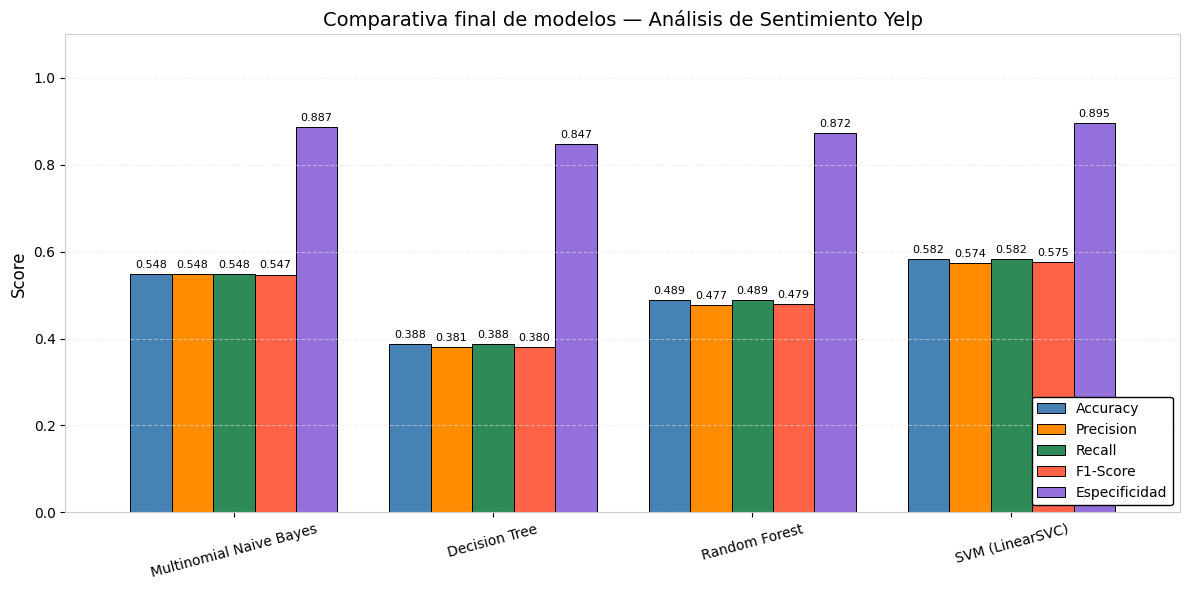

In [ ]:
#@title ### *5. Comparativa Final*

modelos_eval = []
if 'y_pred_mnb' in locals(): modelos_eval.append(("Multinomial NB", y_pred_mnb))
if 'y_pred_dt'  in locals(): modelos_eval.append(("Decision Tree",  y_pred_dt))
if 'y_pred_rf'  in locals(): modelos_eval.append(("Random Forest",  y_pred_rf))
if 'y_pred_svm' in locals(): modelos_eval.append(("SVM",            y_pred_svm))

resultados = {"Modelo": [], "Accuracy": [], "Precision": [], "Recall": [], "F1-Score": [], "Especificidad": []}

for name, pred in modelos_eval:
    resultados["Modelo"].append(name)
    resultados["Accuracy"].append(accuracy_score(y_test, pred))
    resultados["Precision"].append(precision_score(y_test, pred, average='weighted', zero_division=0))
    resultados["Recall"].append(recall_score(y_test, pred, average='weighted', zero_division=0))
    resultados["F1-Score"].append(f1_score(y_test, pred, average='weighted', zero_division=0))
    resultados["Especificidad"].append(especificidad_multiclase(y_test, pred))

df_resultados = pd.DataFrame(resultados).set_index("Modelo")
display(df_resultados.round(4))

# ─────────────────────────────────────────────
# Gráfico comparativo
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

df_resultados.plot(
    kind="bar",
    ax=ax,
    ylim=(0.0, 1.1),
    colormap="tab10",
    edgecolor="black",
    width=0.8,
)

ax.set_title("Comparativa final de modelos — Análisis de Sentimiento Yelp", fontsize=14)
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', linestyle='--', alpha=0.6) # Agrega las líneas punteadas de fondo
ax.legend(loc="lower right")

# Etiquetas de valor encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()


##  ***Tercera Parte***
### *Entrenamiento por Deep Learning*
- *tiempo estimado (~50 minutos)*

---
---

### **3.1 Entrenamiento de modelo**

- Generador de datos y metricas.
- Entrenamiento. (~25 minutos)
- Curvas de datos.
- Resulatados ablation study. (~25 minutos)
- Grafiaca comparativa modelos


---

In [ ]:

#@title  #### *1. Generador de datos y metricas*
class SparseDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=128, shuffle=True):
        super().__init__()
        self.X = X
        self.y = y.values if hasattr(y, 'values') else y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(self.X.shape[0])
        if self.shuffle: np.random.shuffle(self.indices)

    def __len__(self): return int(np.ceil(self.X.shape[0] / self.batch_size))

    def __getitem__(self, index):
        idx = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        return self.X[idx].toarray(), tf.keras.utils.to_categorical(self.y[idx], 5)

    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.indices)

train_gen = SparseDataGenerator(X_train_final, y_train, batch_size=128)
test_gen  = SparseDataGenerator(X_test_final,  y_test,  batch_size=128, shuffle=False)
input_dim = X_train_final.shape[1]

# ─── FUNCIÓN DE MÉTRICAS ─────────────────────────────────────
def get_full_metrics(model, gen, name):
    y_pred, y_true = [], []
    for i in range(len(gen)):
        bx, by = gen[i]
        y_pred.extend(np.argmax(model.predict(bx, verbose=0), axis=1))
        y_true.extend(np.argmax(by, axis=1))
    return {
        'Modelo':     name,
        'Accuracy':   accuracy_score(y_true, y_pred),
        'Precision':  precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall':     recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score':   f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

def get_sklearn_metrics(model, X_test, y_test, name):
    X_dense = X_test.toarray() if hasattr(X_test, 'toarray') else X_test
    y_pred = model.predict(X_dense)
    return {
        'Modelo':    name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

In [ ]:
#@title #### *2. Entrenamiento del modelo DNN*

# ============================================================
# 1. ENTRENAMIENTO — ARQUITECTURA 1 (Base)
# ============================================================
print("Entrenando Arquitectura 1 (DNN Base)...")
# Arquitectura simple: 2 capas ocultas, ReLU, Dropout, Adam lr=0.001
model1 = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])
model1.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
h1 = model1.fit(train_gen, validation_data=test_gen, epochs=15, verbose=0)
print("Arquitectura 1 lista.")

# ============================================================
# 2. ENTRENAMIENTO — ARQUITECTURA 2 (Regularizada + BN)
# ============================================================
print("Entrenando Arquitectura 2 (DNN Regularizada + BatchNorm)...")
# Más capas, ELU, BatchNormalization, learning rate más bajo, RMSprop
model2 = Sequential([
    Input(shape=(input_dim,)),
    Dense(512, activation='elu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='elu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='elu'),
    Dropout(0.2),
    Dense(5, activation='softmax')
])
model2.compile(optimizer=RMSprop(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
h2 = model2.fit(train_gen, validation_data=test_gen, epochs=15, verbose=0)
print("Arquitectura 2 lista.")

▶ Entrenando Arquitectura 1 (DNN Base)...
  ✔ Arquitectura 1 lista.
▶ Entrenando Arquitectura 2 (DNN Regularizada + BatchNorm)...
  ✔ Arquitectura 2 lista.


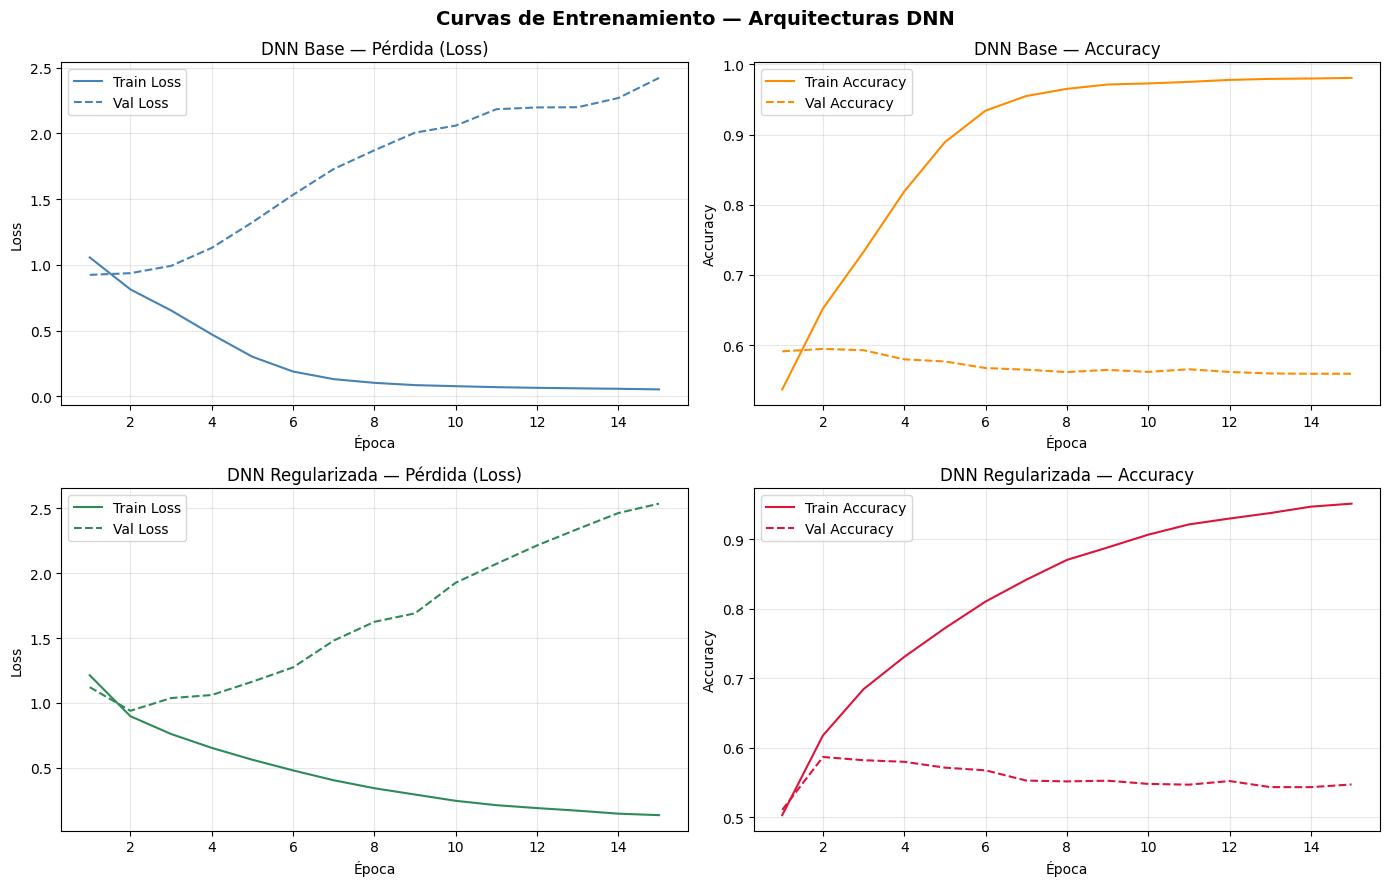

In [ ]:
#@title #### *3. Curvas de entrenamiento (Loss y Accuracy)*

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Curvas de Entrenamiento — Arquitecturas DNN", fontsize=14, fontweight='bold')

epochs_range = range(1, len(h1.history['loss']) + 1)

# Arquitectura 1 — Loss
axes[0, 0].plot(epochs_range, h1.history['loss'],     label='Train Loss',      color='steelblue')
axes[0, 0].plot(epochs_range, h1.history['val_loss'], label='Val Loss',        color='steelblue', linestyle='--')
axes[0, 0].set_title("DNN Base — Pérdida (Loss)")
axes[0, 0].set_xlabel("Época"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Arquitectura 1 — Accuracy
axes[0, 1].plot(epochs_range, h1.history['accuracy'],     label='Train Accuracy', color='darkorange')
axes[0, 1].plot(epochs_range, h1.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linestyle='--')
axes[0, 1].set_title("DNN Base — Accuracy")
axes[0, 1].set_xlabel("Época"); axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

epochs_range2 = range(1, len(h2.history['loss']) + 1)

# Arquitectura 2 — Loss
axes[1, 0].plot(epochs_range2, h2.history['loss'],     label='Train Loss',  color='seagreen')
axes[1, 0].plot(epochs_range2, h2.history['val_loss'], label='Val Loss',    color='seagreen', linestyle='--')
axes[1, 0].set_title("DNN Regularizada — Pérdida (Loss)")
axes[1, 0].set_xlabel("Época"); axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# Arquitectura 2 — Accuracy
axes[1, 1].plot(epochs_range2, h2.history['accuracy'],     label='Train Accuracy', color='crimson')
axes[1, 1].plot(epochs_range2, h2.history['val_accuracy'], label='Val Accuracy',   color='crimson', linestyle='--')
axes[1, 1].set_title("DNN Regularizada — Accuracy")
axes[1, 1].set_xlabel("Época"); axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


▶ Ejecutando Ablation Study completo...

─── RESULTADOS ABLATION STUDY ───────────────────────────


,Hiperparámetro,Modelo,Accuracy,Precision,Recall,F1-Score
0,Cantidad de Neuronas,Neuronas=64,0.5718,0.5675,0.5718,0.5688
1,Cantidad de Neuronas,Neuronas=128,0.5656,0.5630,0.5656,0.5640
2,Cantidad de Neuronas,Neuronas=256,0.5580,0.5558,0.5580,0.5564
3,Cantidad de Neuronas,Neuronas=512,0.5577,0.5547,0.5577,0.5540
4,Número de Capas,Capas=1,0.5659,0.5635,0.5659,0.5606
5,Número de Capas,Capas=2,0.5479,0.5542,0.5479,0.5496
6,Número de Capas,Capas=3,0.5535,0.5594,0.5535,0.5554
7,Función de Activación,Activación=relu,0.5410,0.5422,0.5410,0.5385
8,Función de Activación,Activación=elu,0.5528,0.5510,0.5528,0.5514
9,Función de Activación,Activación=tanh,0.5520,0.5517,0.5520,0.5494


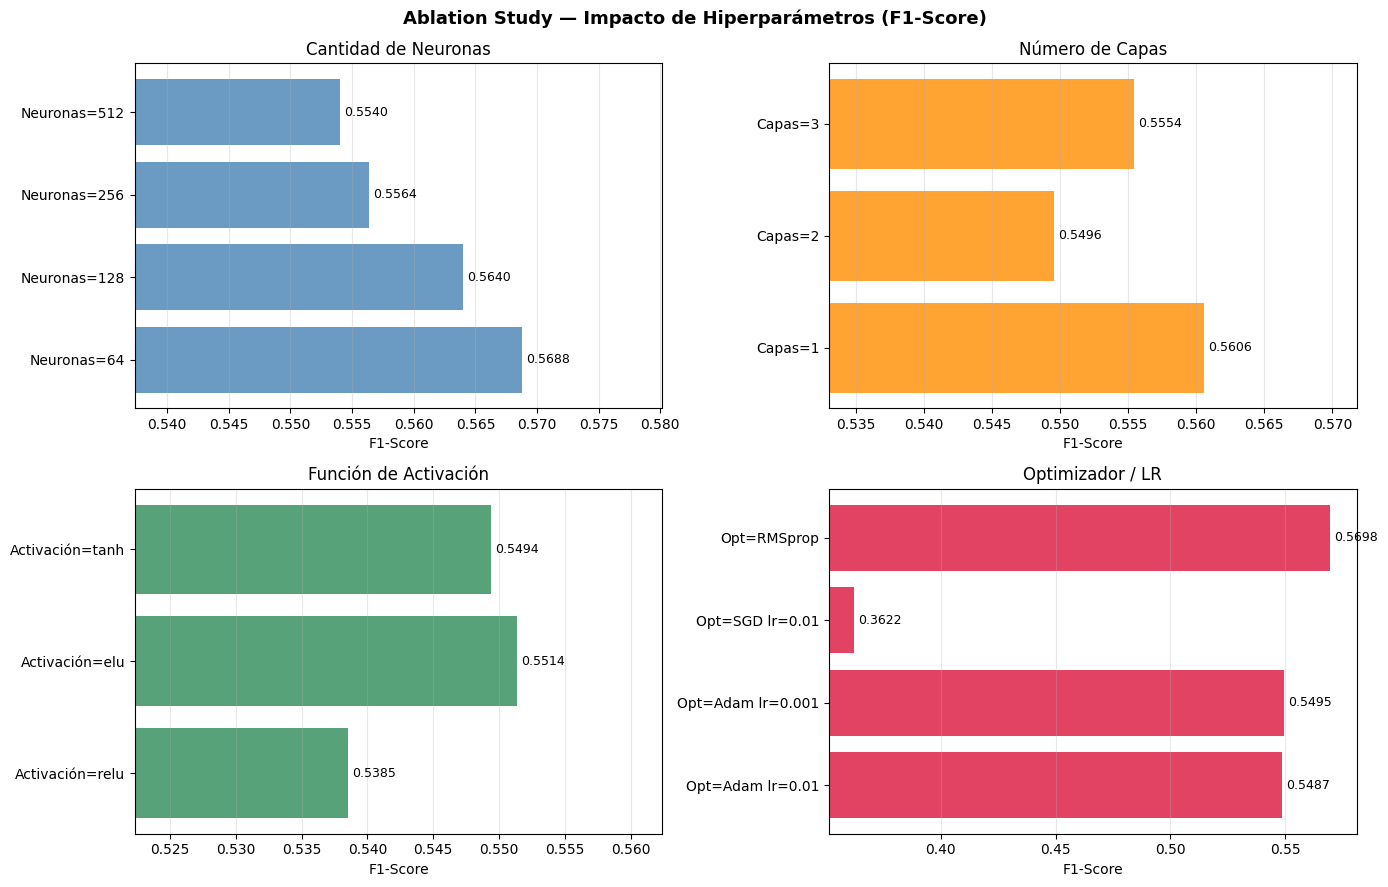

In [ ]:
#@title #### *4. Resulatados de ablation Study*

print("\nEjecutando Ablation Study completo...")

ablation_results = []

# A) Número de neuronas (1 capa oculta)
for neurons in [64, 128, 256, 512]:
    m = Sequential([Input(shape=(input_dim,)), Dense(neurons, activation='relu'), Dense(5, activation='softmax')])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    m.fit(train_gen, epochs=5, verbose=0)
    r = get_full_metrics(m, test_gen, f"Neuronas={neurons}")
    r['Hiperparámetro'] = 'Cantidad de Neuronas'
    ablation_results.append(r)

# B) Número de capas ocultas
for n_layers in [1, 2, 3]:
    layers = [Input(shape=(input_dim,))]
    for _ in range(n_layers):
        layers_list = [Input(shape=(input_dim,))]
    capas = [Input(shape=(input_dim,))]
    # Construir dinámicamente
    m = Sequential()
    m.add(Input(shape=(input_dim,)))
    for _ in range(n_layers):
        m.add(Dense(128, activation='relu'))
    m.add(Dense(5, activation='softmax'))
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    m.fit(train_gen, epochs=5, verbose=0)
    r = get_full_metrics(m, test_gen, f"Capas={n_layers}")
    r['Hiperparámetro'] = 'Número de Capas'
    ablation_results.append(r)

# C) Funciones de activación
for act in ['relu', 'elu', 'tanh']:
    m = Sequential([Input(shape=(input_dim,)), Dense(128, activation=act), Dense(64, activation=act), Dense(5, activation='softmax')])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    m.fit(train_gen, epochs=5, verbose=0)
    r = get_full_metrics(m, test_gen, f"Activación={act}")
    r['Hiperparámetro'] = 'Función de Activación'
    ablation_results.append(r)

# D) Learning Rate y Optimizadores
for opt_name, opt in [('Adam lr=0.01', Adam(0.01)), ('Adam lr=0.001', Adam(0.001)),
                       ('SGD lr=0.01', SGD(0.01)), ('RMSprop', RMSprop(0.001))]:
    m = Sequential([Input(shape=(input_dim,)), Dense(128, activation='relu'), Dense(64, activation='relu'), Dense(5, activation='softmax')])
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    m.fit(train_gen, epochs=5, verbose=0)
    r = get_full_metrics(m, test_gen, f"Opt={opt_name}")
    r['Hiperparámetro'] = 'Optimizador / LR'
    ablation_results.append(r)

df_ablation = pd.DataFrame(ablation_results)[['Hiperparámetro', 'Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
print("\n─── RESULTADOS ABLATION STUDY ───────────────────────────")
display(df_ablation.round(4))

# Gráfica del ablation study
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Ablation Study — Impacto de Hiperparámetros (F1-Score)", fontsize=13, fontweight='bold')

grupos = ['Cantidad de Neuronas', 'Número de Capas', 'Función de Activación', 'Optimizador / LR']
colores = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for ax, grupo, color in zip(axes.flat, grupos, colores):
    sub = df_ablation[df_ablation['Hiperparámetro'] == grupo]
    bars = ax.barh(sub['Modelo'], sub['F1-Score'], color=color, alpha=0.8)
    ax.set_xlim(sub['F1-Score'].min() * 0.97, sub['F1-Score'].max() * 1.02)
    ax.set_title(grupo)
    ax.set_xlabel("F1-Score")
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()



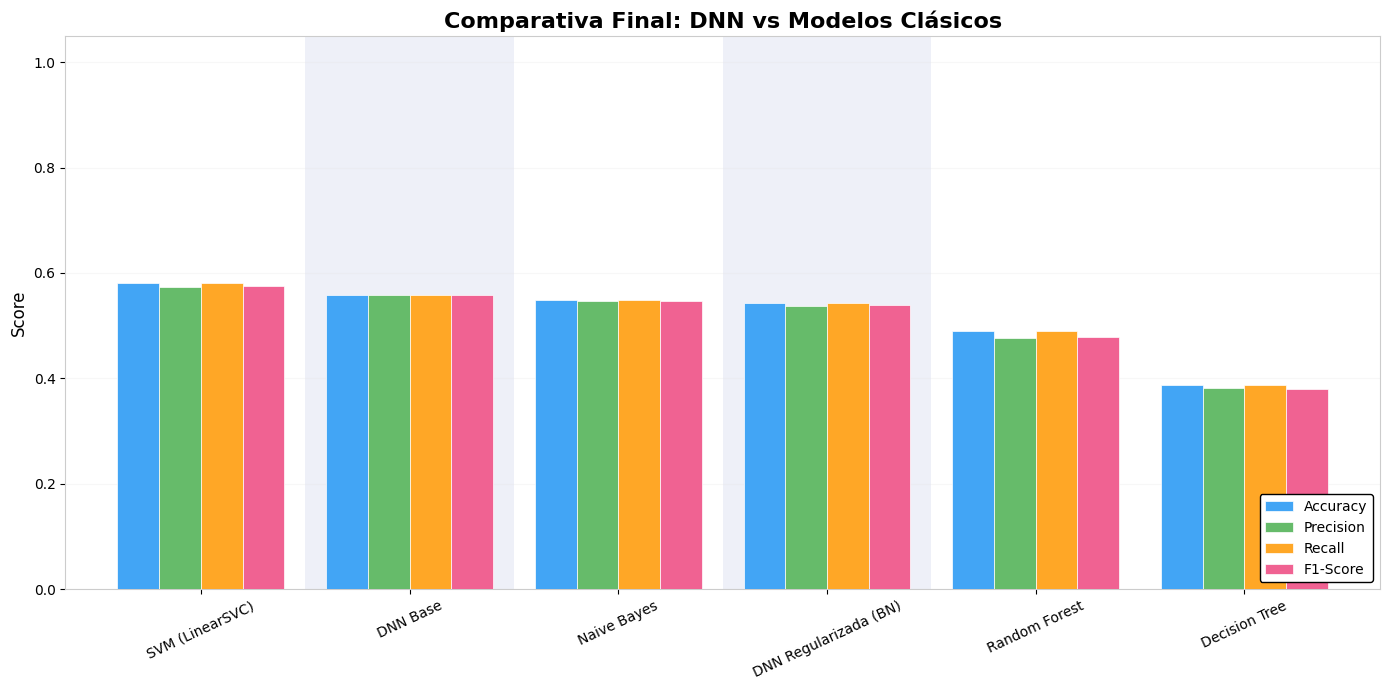

In [ ]:
#@title ### *5. Grafiaca comparativa modelos*
def metrics_from_preds(y_true, y_pred, name):
    return {
        'Modelo':    name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score':  f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

results_classical = [
    metrics_from_preds(y_test, y_pred_mnb, "Naive Bayes"),
    metrics_from_preds(y_test, y_pred_dt,  "Decision Tree"),
    metrics_from_preds(y_test, y_pred_rf,  "Random Forest"),
    metrics_from_preds(y_test, y_pred_svm, "SVM (LinearSVC)"),
]

# ============================================================
# 6. TABLA COMPARATIVA FINAL — DNN vs Modelos Clásicos
# ============================================================
results_dnn = [
    get_full_metrics(model1, test_gen, "DNN Base"),
    get_full_metrics(model2, test_gen, "DNN Regularizada (BN)")
]

df_comparison = pd.DataFrame(results_dnn + results_classical)
df_comparison['Tipo'] = (['Deep Learning'] * 2) + (['Clásico'] * 4)
df_comparison = df_comparison[['Tipo', 'Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
df_comparison = df_comparison.sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_comparison.index += 1

print("\n─── TABLA COMPARATIVA FINAL: DNN vs Modelos Clásicos ───")
display(df_comparison.round(4))

# Gráfica comparativa final
fig, ax = plt.subplots(figsize=(12, 6))
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_comparison))
width = 0.2
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (metrica, color) in enumerate(zip(metricas, colors_bar)):
    ax.bar(x + i * width, df_comparison[metrica], width, label=metrica, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_comparison['Modelo'], rotation=25, ha='right', fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Comparativa Final: DNN vs Modelos Clásicos", fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

for idx in df_comparison[df_comparison['Tipo'] == 'Deep Learning'].index - 1:
    ax.axvspan(idx - 0.15, idx + 4 * width + 0.05, alpha=0.07, color='blue')

plt.tight_layout()
plt.show()



##  ***Cuarto Parte***
### *Entrenamiento no supervisado*

- *tiempo estimado (~10 minutos)*

---

In [ ]:
#@title ### *1. Configuracion e inicailización*

# ── Parámetros ← ajusta según tu dataset ─────────────────────────────────────
N_SVD      = 50       # < min(n_muestras, n_features)
N_CLUSTERS = 5
N_VIZ      = 10000   # puntos para t-SNE / PCA 2D-3D (↓ = menos RAM)
N_AGG      = 1500    # submuestra Agglomerative
N_DB       = 5000    # submuestra DBSCAN
N_DEND     = 200      # submuestra dendrograma
EPS        = None     # None → se calcula automático con k-dist
MIN_PTS    = 10
SEED       = 42

# ── Paleta ────────────────────────────────────────────────────────────────────
COLORES     = ['#e41a1c', '#ff7f00', '#4daf4a', '#377eb8', '#984ea3']
NOMBRES     = ['1★', '2★', '3★', '4★', '5★']
AZUL        = '#2563eb'
ROJO        = '#dc2626'
NARANJA     = '#ea580c'
VERDE       = '#16a34a'
COLOR_RUIDO = '#cccccc'

plt.rcParams.update({
    'axes.facecolor':  'white', 'figure.facecolor': 'white',
    'axes.edgecolor':  '#ccc',  'grid.color':        '#e5e5e5',
    'grid.linewidth':  0.8,     'font.family':       'DejaVu Sans',
})

rng = np.random.default_rng(SEED)

print("parámetros e inicialización listos.")


# ── Utilidades ────────────────────────────────────────────────────────────────

def subsample(X, y, n):
    """Devuelve índices y submatrices aleatorias de tamaño n."""
    idx = rng.choice(len(X), min(n, len(X)), replace=False)
    return idx, X[idx], y[idx]


def imprimir_tabla(df, titulo):
    print(f"\n{'═'*70}\n  {titulo}\n{'═'*70}")
    print(df.round(4).to_string())
    print('═'*70)


def score_global(row):
    """Puntaje compuesto: Sil + ARI + NMI - DB (para elegir mejor modelo)."""
    return (
        (0 if np.isnan(row['Silhouette ↑']) else row['Silhouette ↑'])
        + row['ARI ↑'] + row['NMI ↑']
        - (0 if np.isnan(row['Davies-Bouldin ↓']) else row['Davies-Bouldin ↓'])
    )

# ── TruncatedSVD ──────────────────────────────────────────────────────────────
print("► TruncatedSVD...", end=' ')
svd       = TruncatedSVD(n_components=N_SVD, random_state=SEED)
X_svd     = normalize(svd.fit_transform(X_train_final)).astype(np.float32)
var_total = svd.explained_variance_ratio_.sum()
print(f"varianza={var_total:.3f} | shape={X_svd.shape}")

y_idx = y_train.values - 1   # etiquetas 0-based

print("X_svd disponible.")



parámetros e inicialización listos.
► TruncatedSVD... varianza=0.791 | shape=(40000, 50)
X_svd disponible.


In [ ]:
#@title ### *2. Algoritmos de clustering*


# ── 3.1 K-Means: curva del codo + modelo final ───────────────────────────────
print("► K-Means...", end=' ')
ks       = list(range(2, 12))
inertias = [
    MiniBatchKMeans(n_clusters=k, random_state=SEED, n_init=3)
    .fit(X_svd).inertia_
    for k in ks
]
kmeans    = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
labels_km = kmeans.fit_predict(X_svd)
print(f"distribución={np.bincount(labels_km)}")

# ── 3.2 Agglomerative: submuestra (O(n²) en memoria) ─────────────────────────
print("► Agglomerative...", end=' ')
idx_agg, X_agg, y_agg = subsample(X_svd, y_idx, N_AGG)
labels_agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward') \
             .fit_predict(X_agg)
idx_dend   = rng.choice(len(X_agg), min(N_DEND, len(X_agg)), replace=False)
print(f"distribución={np.bincount(labels_agg)}")

# ── 3.3 DBSCAN: búsqueda automática de EPS para ~N_CLUSTERS clusters ─────────
def buscar_eps(X_sub, min_pts, objetivo=5, pasos=50):
    nn = NearestNeighbors(n_neighbors=min_pts).fit(X_sub)
    dists, _ = nn.kneighbors(X_sub)
    k_dists  = np.sort(dists[:, -1])

    mejor_eps, mejor_diff, mejor_labels = None, np.inf, None
    for p in np.linspace(10, 99, pasos):
        eps    = float(np.percentile(k_dists, p))
        labels = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X_sub)
        n_cls  = len(set(labels)) - (-1 in labels)
        diff   = abs(n_cls - objetivo)
        print(f"  p={p:4.0f}  eps={eps:.4f}  clusters={n_cls:3d}  "
              f"ruido={(labels == -1).sum():4d}")
        if diff < mejor_diff:
            mejor_diff, mejor_eps, mejor_labels = diff, eps, labels
        if n_cls == objetivo:
            print(f"\nExacto: eps={eps:.4f} → {n_cls} clusters")
            return eps, labels
    print(f"\nMejor aproximación: eps={mejor_eps:.4f} "
          f"→ {len(set(mejor_labels)) - (-1 in mejor_labels)} clusters")
    return mejor_eps, mejor_labels


idx_db, X_db, y_db = subsample(X_svd, y_idx, N_DB)
print("DBSCAN buscando ~5 clusters...")
eps_val, labels_db = buscar_eps(X_db, MIN_PTS, objetivo=N_CLUSTERS)

n_cls_db   = len(set(labels_db)) - (-1 in labels_db)
n_noise_db = (labels_db == -1).sum()
print(f"\nEPS={eps_val:.4f} | clústeres={n_cls_db} | "
      f"ruido={n_noise_db} ({100 * n_noise_db / len(X_db):.1f}%)")



► K-Means... distribución=[21344  3697  7256  5383  2320]
► Agglomerative... distribución=[173 167 217 753 190]
DBSCAN buscando ~5 clusters...
  p=  10  eps=0.0704  clusters= 11  ruido=3836
  p=  12  eps=0.0718  clusters= 10  ruido=3695
  p=  14  eps=0.0729  clusters= 12  ruido=3532
  p=  15  eps=0.0739  clusters= 12  ruido=3416
  p=  17  eps=0.0748  clusters= 12  ruido=3305
  p=  19  eps=0.0758  clusters= 12  ruido=3168
  p=  21  eps=0.0769  clusters= 12  ruido=3060
  p=  23  eps=0.0778  clusters= 12  ruido=2961
  p=  25  eps=0.0785  clusters= 13  ruido=2875
  p=  26  eps=0.0796  clusters= 14  ruido=2763
  p=  28  eps=0.0804  clusters= 14  ruido=2686
  p=  30  eps=0.0814  clusters= 13  ruido=2582
  p=  32  eps=0.0822  clusters= 15  ruido=2484
  p=  34  eps=0.0832  clusters= 16  ruido=2400
  p=  35  eps=0.0841  clusters= 15  ruido=2310
  p=  37  eps=0.0850  clusters= 15  ruido=2219
  p=  39  eps=0.0858  clusters= 16  ruido=2137
  p=  41  eps=0.0867  clusters= 15  ruido=2055
  p=  43  e

In [ ]:
#@title ### *3. Métricas de evaluación*


# ── Utilidades de alineación y cálculo ───────────────────────────────────────

def hungarian_align(y_true, y_pred):
    mask = y_pred != -1
    yt, yp = y_true[mask], y_pred[mask]
    D    = max(yt.max() + 1, yp.max() + 1)
    cost = np.zeros((D, D), dtype=int)
    for i, j in zip(yt, yp):
        cost[i, j] += 1
    row, col  = linear_sum_assignment(-cost)
    mapping   = {c: r for r, c in zip(row, col)}
    y_aligned = y_pred.copy().astype(int)
    y_aligned[mask] = np.array([mapping.get(int(p), -1) for p in yp])
    return y_aligned, mask


def metricas_clustering(X, y_true, y_pred):

    mask = y_pred != -1
    Xf, yf, pf = X[mask], y_true[mask], y_pred[mask]

    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    vm  = v_measure_score(y_true, y_pred)          # ← nuevo
    fmi = fowlkes_mallows_score(y_true, y_pred)    # ← nuevo

    if len(np.unique(pf)) < 2:
        return dict(
            Silhouette=np.nan, ARI=ari, NMI=nmi, VM=vm, FMI=fmi,
            CH=np.nan, DB=np.nan,
        )
    return dict(
        Silhouette=silhouette_score(Xf, pf),
        ARI=ari, NMI=nmi, VM=vm, FMI=fmi,
        CH=calinski_harabasz_score(Xf, pf),
        DB=davies_bouldin_score(Xf, pf),
    )


def metricas_clasificacion(y_true, y_pred):
    y_alin, mask = hungarian_align(y_true, y_pred)
    yt, yp       = y_true[mask], y_alin[mask]
    labels_u     = np.unique(yt)

    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, average='macro', zero_division=0)
    rec  = recall_score(yt, yp, average='macro', zero_division=0)
    f1   = f1_score(yt, yp, average='macro', zero_division=0)
    cm   = confusion_matrix(yt, yp, labels=labels_u)

    espec = np.mean([
        (cm.sum() - cm[i].sum() - cm[:, i].sum() + cm[i, i]) /
        max(
            (cm.sum() - cm[i].sum() - cm[:, i].sum() + cm[i, i]) +
            (cm[:, i].sum() - cm[i, i]), 1
        )
        for i in range(len(labels_u))
    ])

    mcc   = matthews_corrcoef(yt, yp)
    kappa = cohen_kappa_score(yt, yp)

    return dict(
        Accuracy=acc, Precision=prec, Recall=rec,
        F1_Score=f1, Especificidad=espec,
        MCC=mcc, Kappa=kappa,
    )

# ── 4.1 Calcular métricas clustering ─────────────────────────────────────────
print("► Métricas clustering...")
rows_clust = {
    'K-Means':       metricas_clustering(X_svd, y_idx,  labels_km),
    'Agglomerative': metricas_clustering(X_agg, y_agg,  labels_agg),
    'DBSCAN':        metricas_clustering(X_db,  y_db,   labels_db),
}
df_clust = pd.DataFrame(rows_clust).T.rename(columns={
    'Silhouette': 'Silhouette ↑',
    'ARI':        'ARI ↑',
    'NMI':        'NMI ↑',
    'VM':         'V-Measure ↑',
    'FMI':        'Fowlkes-Mallows ↑',
    'CH':         'Calinski-Harabasz ↑',
    'DB':         'Davies-Bouldin ↓',
})
mejor = df_clust.apply(score_global, axis=1).idxmax()
imprimir_tabla(df_clust, f'Métricas Clustering  |  Mejor modelo: {mejor}')

# ── 4.2 Calcular métricas clasificación ──────────────────────────────────────
print("► Métricas clasificación...")
rows_clf = {
    'K-Means':       metricas_clasificacion(y_idx, labels_km),
    'Agglomerative': metricas_clasificacion(y_agg, labels_agg),
    'DBSCAN':        metricas_clasificacion(y_db,  labels_db),
}
df_clf = pd.DataFrame(rows_clf).T.rename(columns={'F1_Score': 'F1-Score'})
imprimir_tabla(df_clf, 'Métricas Clasificación — No Supervisado vs Ground Truth')

print("tablas de métricas calculadas.")

► Métricas clustering...

══════════════════════════════════════════════════════════════════════
  Métricas Clustering  |  Mejor modelo: K-Means
══════════════════════════════════════════════════════════════════════
               Silhouette ↑   ARI ↑   NMI ↑  V-Measure ↑  Fowlkes-Mallows ↑  Calinski-Harabasz ↑  Davies-Bouldin ↓
K-Means              0.3738  0.0173  0.0303       0.0303             0.2771           38590.8008            0.9389
Agglomerative        0.3558  0.0124  0.0295       0.0295             0.2602            1438.1316            0.9685
DBSCAN               0.2759  0.0219  0.0350       0.0350             0.2743            1793.0096            1.0705
══════════════════════════════════════════════════════════════════════
► Métricas clasificación...

══════════════════════════════════════════════════════════════════════
  Métricas Clasificación — No Supervisado vs Ground Truth
══════════════════════════════════════════════════════════════════════
               Accuracy 

Preparando submuestra compartida para proyecciones... 10000 puntos
t-SNE 2D (1 ejecución sobre SVD reducido)... 

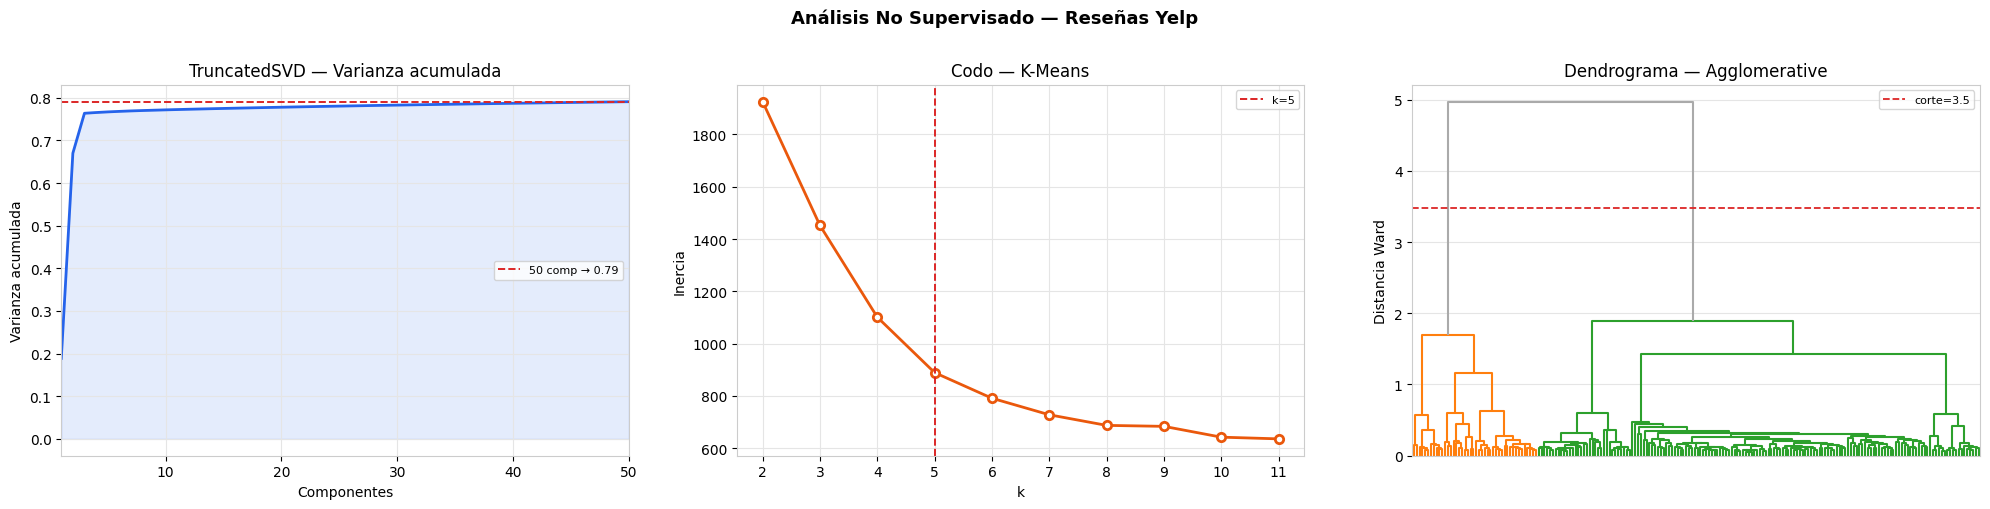

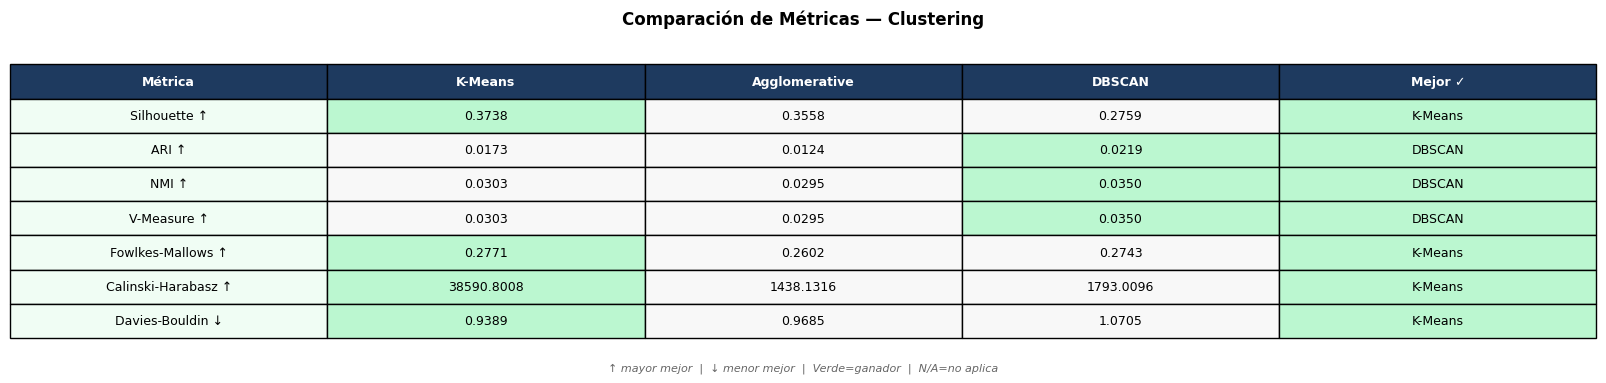

✓ fig2a_metricas_clustering.png guardada


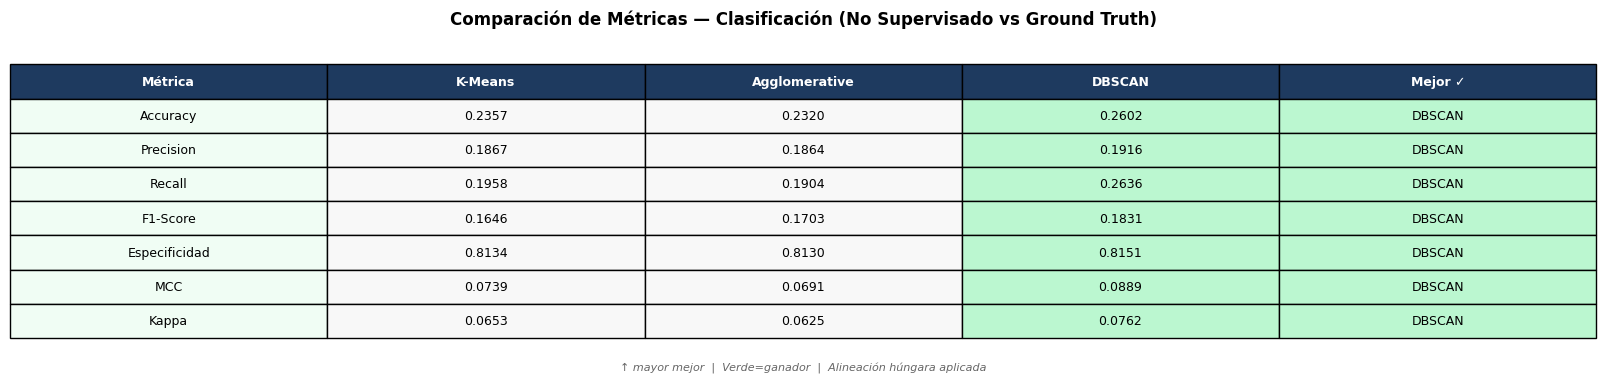

✓ fig2b_metricas_clasificacion.png guardada


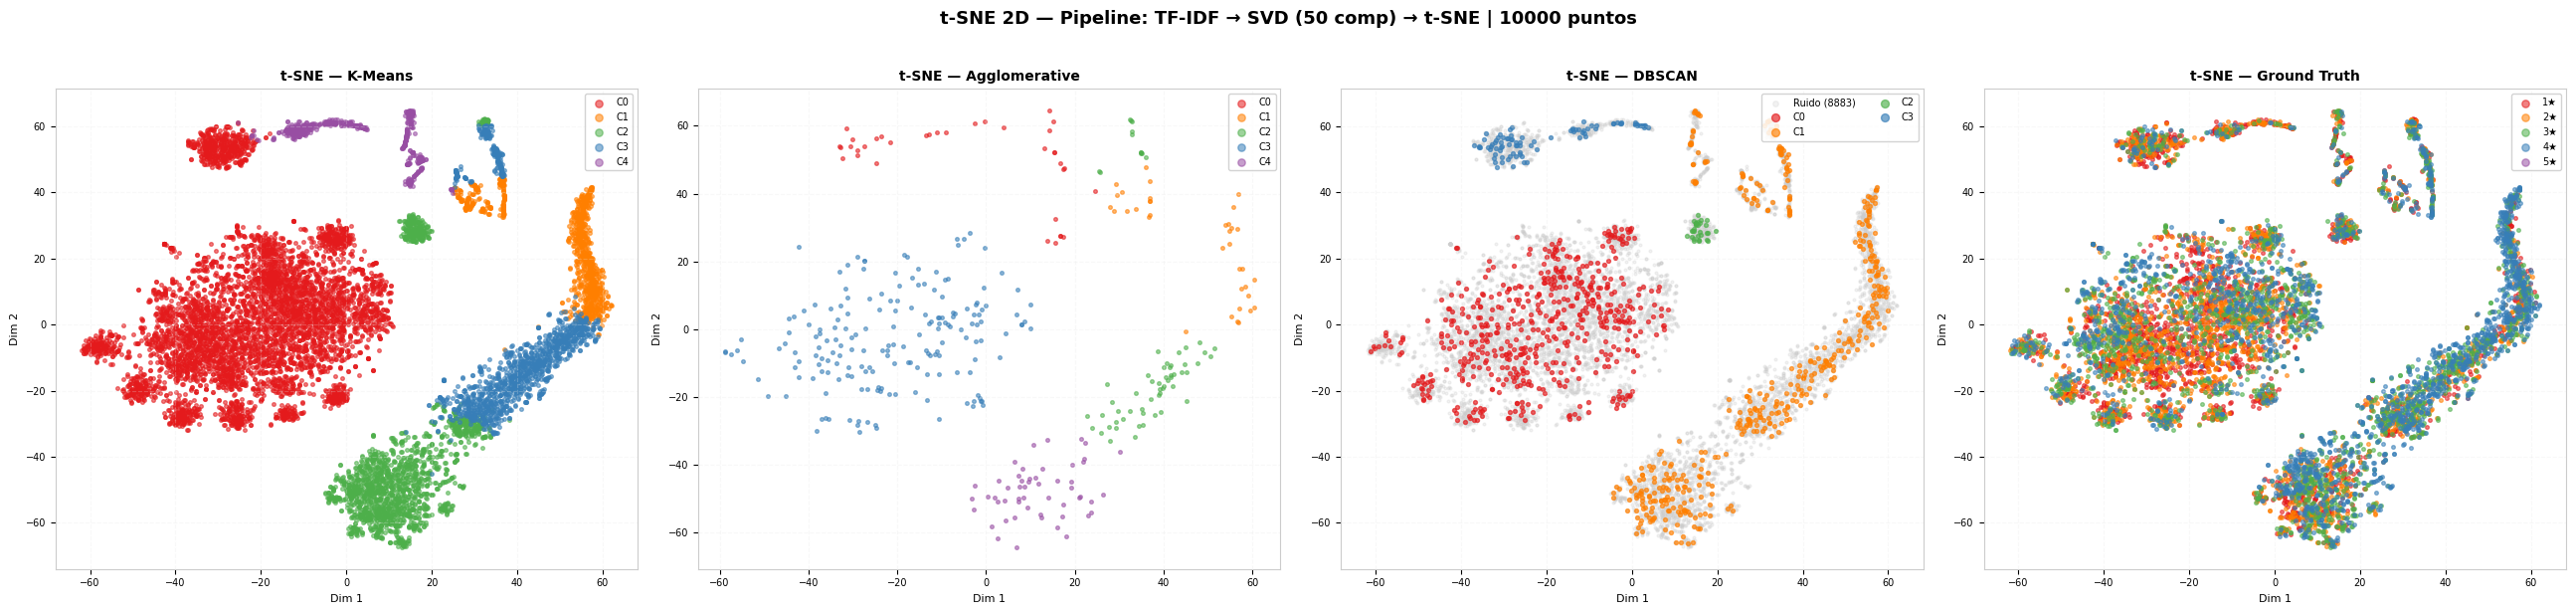

► t-SNE 3D (1 ejecución)... 

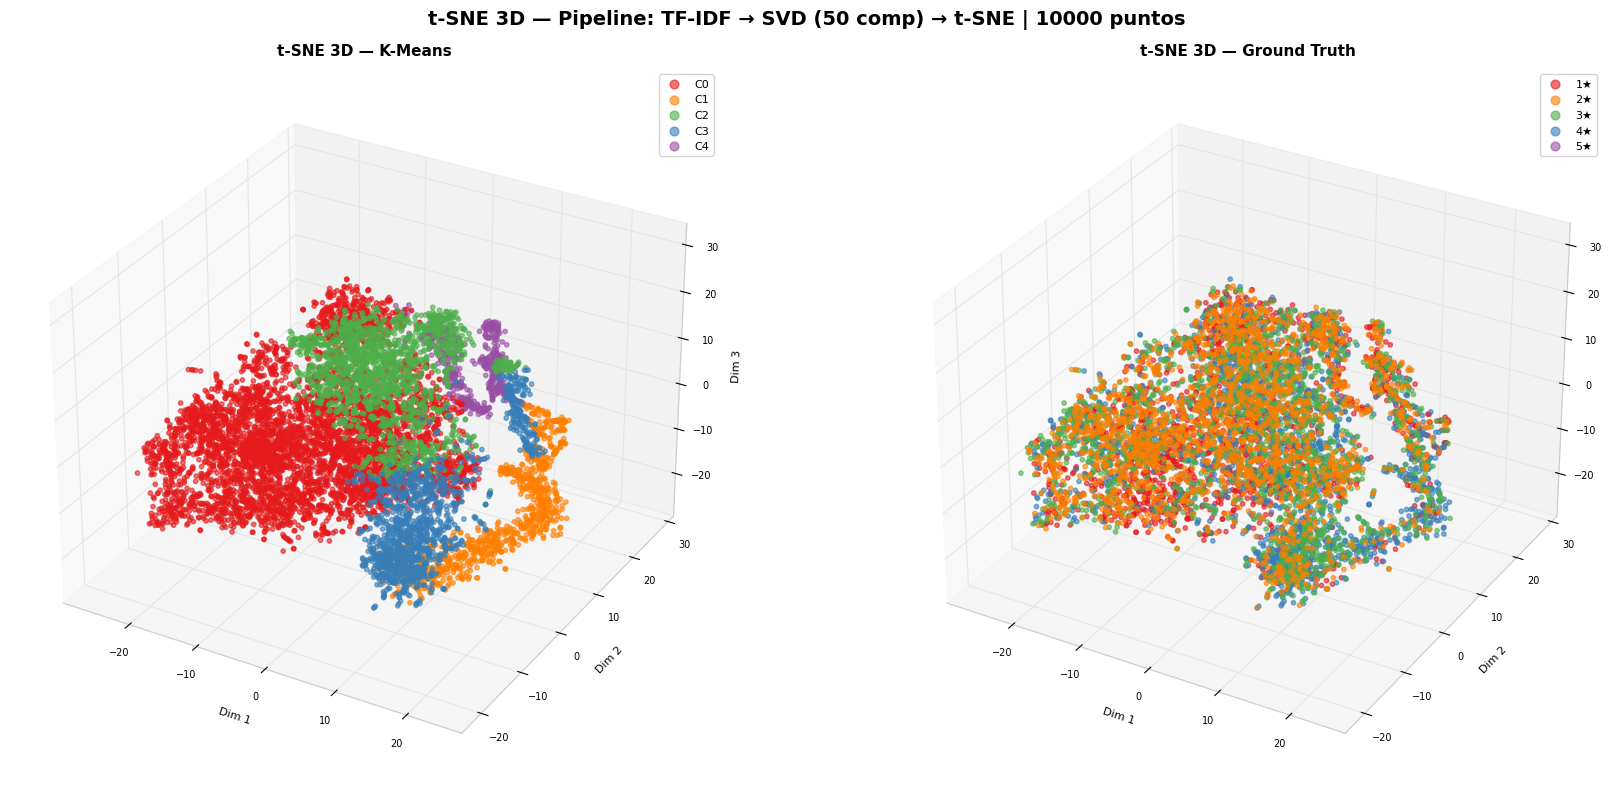

In [ ]:


#@title ### *4. Visualización*
# ── 5.0 Submuestra compartida para t-SNE ─────────────────────────────────────
print("Preparando submuestra compartida para proyecciones...", end=' ')
idx_viz, X_viz, y_viz = subsample(X_svd, y_idx, N_VIZ)

km_viz  = labels_km[idx_viz]
agg_map = dict(zip(idx_agg, labels_agg))
db_map  = dict(zip(idx_db,  labels_db))
agg_viz = np.array([agg_map.get(i, -1) for i in idx_viz])
db_viz  = np.array([db_map.get(i,  -1) for i in idx_viz])
print(f"{len(idx_viz)} puntos")

# ── 5.1 t-SNE 2D (embedding único, 4 coloreos distintos) ─────────────────────
from sklearn.manifold import TSNE
print("t-SNE 2D (1 ejecución sobre SVD reducido)...", end=' ')
tsne_2d = TSNE(
    n_components=2, perplexity=40, init='pca',
    learning_rate='auto', n_iter=1000, n_jobs=-1, random_state=SEED,
).fit_transform(X_viz)


# ── Funciones de scatter ──────────────────────────────────────────────────────
def scatter_panel(ax, X2d, labels, es_db=False, es_gt=False, titulo=''):
    ax.set_facecolor('white')
    if es_db:
        mask_r = labels == -1
        if mask_r.any():
            ax.scatter(X2d[mask_r, 0], X2d[mask_r, 1],
                       s=4, alpha=0.25, color=COLOR_RUIDO,
                       label=f'Ruido ({mask_r.sum()})')
        for i, cid in enumerate(np.unique(labels[labels != -1])):
            m = labels == cid
            ax.scatter(X2d[m, 0], X2d[m, 1], s=8, alpha=0.65,
                       color=COLORES[i % len(COLORES)], label=f'C{cid}')
        ax.legend(markerscale=2, fontsize=7, framealpha=0.85,
                  edgecolor='#ccc', loc='upper right', ncol=2)
    else:
        for c in range(N_CLUSTERS):
            m = labels == c
            ax.scatter(X2d[m, 0], X2d[m, 1], s=7, alpha=0.55,
                       color=COLORES[c],
                       label=NOMBRES[c] if es_gt else f'C{c}')
        ax.legend(markerscale=2, fontsize=7, framealpha=0.85,
                  edgecolor='#ccc', loc='upper right')
    ax.set_title(titulo, fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('Dim 1', fontsize=8)
    ax.set_ylabel('Dim 2', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle='--', alpha=0.25)


def scatter_panel_3d(ax, X3d, labels, es_gt=False, titulo=''):
    ax.set_facecolor('white')
    for c in range(N_CLUSTERS):
        m = labels == c
        ax.scatter(X3d[m, 0], X3d[m, 1], X3d[m, 2],
                   s=10, alpha=0.6, color=COLORES[c % len(COLORES)],
                   label=NOMBRES[c] if es_gt else f'C{c}')
    ax.legend(markerscale=2, fontsize=8, framealpha=0.85,
              edgecolor='#ccc', loc='upper right')
    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Dim 1', fontsize=8)
    ax.set_ylabel('Dim 2', fontsize=8)
    ax.set_zlabel('Dim 3', fontsize=8)
    ax.tick_params(labelsize=7)


# ── 5.2 Tabla visual de métricas (reutilizable) ───────────────────────────────
def tabla_visual(df, filas_cfg, titulo, pie, fname):
    fig, ax = plt.subplots(figsize=(16, 3.8))
    ax.axis('off'); fig.patch.set_facecolor('white')
    modelos = list(df.index)
    cols    = ['Métrica'] + modelos + ['Mejor']
    tdata, tcolors = [], []
    for col, mayor_mejor in filas_cfg:
        vals    = {m: df.loc[m, col] for m in modelos}
        validos = {k: v for k, v in vals.items() if not np.isnan(v)}
        gan     = (
            max(validos, key=validos.get) if mayor_mejor
            else min(validos, key=validos.get)
        ) if validos else '—'
        fmt   = lambda v: f'{v:.4f}' if not np.isnan(v) else 'N/A'
        row   = [col] + [fmt(vals[m]) for m in modelos] + [gan]
        color = ['#f0fdf4'] + \
                ['#bbf7d0' if gan == m else '#f8f8f8' for m in modelos] + \
                ['#bbf7d0']
        tdata.append(row); tcolors.append(color)
    tbl = ax.table(cellText=tdata, colLabels=cols, cellLoc='center',
                   loc='center', cellColours=tcolors)
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2, 1.9)
    for j in range(len(cols)):
        tbl[0, j].set_facecolor('#1e3a5f')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=14)
    fig.text(0.5, 0.01, pie, ha='center', fontsize=8, color='#666', style='italic')
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show(); plt.close(fig)
    print(f"✓ {fname} guardada")


# ── Fig 1 — SVD varianza · Codo · Dendrograma ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
cum = np.cumsum(svd.explained_variance_ratio_)
ax.fill_between(range(1, N_SVD + 1), cum, alpha=0.12, color=AZUL)
ax.plot(range(1, N_SVD + 1), cum, color=AZUL, lw=2)
ax.axhline(var_total, color=ROJO, ls='--', lw=1.4,
           label=f'{N_SVD} comp → {var_total:.2f}')
ax.set(xlabel='Componentes', ylabel='Varianza acumulada',
       title='TruncatedSVD — Varianza acumulada', xlim=(1, N_SVD))
ax.legend(fontsize=8); ax.grid(True)

ax = axes[1]
ax.plot(ks, inertias, 'o-', color=NARANJA, lw=2, ms=6, mfc='white', mew=2)
ax.axvline(N_CLUSTERS, color=ROJO, ls='--', lw=1.4, label=f'k={N_CLUSTERS}')
ax.set(xlabel='k', ylabel='Inercia', title='Codo — K-Means')
ax.set_xticks(ks); ax.legend(fontsize=8); ax.grid(True)

ax = axes[2]
lm     = hierarchy.linkage(X_agg[idx_dend], method='ward')
umbral = 0.7 * lm[:, 2].max()
hierarchy.dendrogram(lm, ax=ax, no_labels=True,
                     color_threshold=umbral, above_threshold_color='#aaa')
ax.axhline(umbral, color=ROJO, ls='--', lw=1.3, label=f'corte={umbral:.1f}')
ax.set(ylabel='Distancia Ward', title='Dendrograma — Agglomerative')
ax.legend(fontsize=8); ax.grid(True, axis='y')
ax.tick_params(axis='x', bottom=False)

fig.suptitle('Análisis No Supervisado — Reseñas Yelp',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(w_pad=2.5)
plt.savefig('fig1_svd_codo_dendrograma.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show(); plt.close(fig)
del lm; gc.collect()


# ── Fig 2a — Tabla clustering (ahora con V-Measure y Fowlkes-Mallows) ────────
tabla_visual(
    df_clust,
    [
        ('Silhouette ↑',         True),
        ('ARI ↑',                True),
        ('NMI ↑',                True),
        ('V-Measure ↑',          True),
        ('Fowlkes-Mallows ↑',    True),
        ('Calinski-Harabasz ↑',  True),
        ('Davies-Bouldin ↓',     False),
    ],
    'Comparación de Métricas — Clustering',
    '↑ mayor mejor  |  ↓ menor mejor  |  Verde=ganador  |  N/A=no aplica',
    'fig2a_metricas_clustering.png',
)

# ── Fig 2b — Tabla clasificación (ahora con MCC y Kappa) ─────────────────────
tabla_visual(
    df_clf,
    [
        ('Accuracy',      True),
        ('Precision',     True),
        ('Recall',        True),
        ('F1-Score',      True),
        ('Especificidad', True),
        ('MCC',           True),   # ← nuevo
        ('Kappa',         True),   # ← nuevo
    ],
    'Comparación de Métricas — Clasificación (No Supervisado vs Ground Truth)',
    '↑ mayor mejor  |  Verde=ganador  |  Alineación húngara aplicada',
    'fig2b_metricas_clasificacion.png',
)

# ── Fig 3 — t-SNE 2D (4 paneles, mismo embedding) ────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(26, 6))
fig.patch.set_facecolor('white')

paneles_tsne = [
    ('t-SNE — K-Means',       km_viz,  False, False),
    ('t-SNE — Agglomerative', agg_viz, False, False),
    ('t-SNE — DBSCAN',        db_viz,  True,  False),
    ('t-SNE — Ground Truth',  y_viz,   False, True),
]
for ax, (titulo, lv, db_flag, gt_flag) in zip(axes, paneles_tsne):
    scatter_panel(ax, tsne_2d, lv, es_db=db_flag, es_gt=gt_flag, titulo=titulo)

fig.suptitle(
    f't-SNE 2D — Pipeline: TF-IDF → SVD ({N_SVD} comp) → t-SNE | {len(idx_viz)} puntos',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.savefig('fig3_tsne_2d.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); plt.close(fig)


# ── Fig 4 — t-SNE 3D (K-Means vs Ground Truth) ───────────────────────────────
print("► t-SNE 3D (1 ejecución)...", end=' ')
tsne_3d = TSNE(
    n_components=3, perplexity=40, init='pca',
    learning_rate='auto', n_iter=1000, n_jobs=-1, random_state=777,
).fit_transform(X_viz)


fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor('white')
ax1 = fig.add_subplot(121, projection='3d')
scatter_panel_3d(ax1, tsne_3d, km_viz, es_gt=False, titulo='t-SNE 3D — K-Means')
ax2 = fig.add_subplot(122, projection='3d')
scatter_panel_3d(ax2, tsne_3d, y_viz,  es_gt=True,  titulo='t-SNE 3D — Ground Truth')
fig.suptitle(
    f't-SNE 3D — Pipeline: TF-IDF → SVD ({N_SVD} comp) → t-SNE | {len(idx_viz)} puntos',
    fontsize=14, fontweight='bold', y=0.98,
)
plt.tight_layout()
plt.savefig('fig4_tsne_3d.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show(); plt.close(fig)
